# Fine-tuning `stabilityai/stable-code-3b` for Code Summarization

## LLM Fine-tuning Assignment

**Task:** Code Summarization — generate concise natural language summaries from code snippets.

**Model:** `stabilityai/stable-code-3b` (3B parameter decoder-only Transformer, GPT-NeoX based)

**Fine-tuning:** QLoRA (4-bit NF4 quantization + Low-Rank Adaptation)

**Datasets:**
1. **CodeSearchNet** (Python) — `code_search_net`
2. **FunCom** (Java) — `apcl/funcom-java-long`

**Sections:**
1. Setup & Dependencies
2. Data Loading & Exploration
3. Tokenization & Preprocessing
4. Model Loading (QLoRA)
5. Fine-tuning (both datasets)
6. Evaluation
7. Hyperparameter Sweep
8. Mechanistic Interpretability
9. Error Analysis
10. Summary Report

---
### Estimated Runtime

| Stage | L40S (48 GB) | A100 (80 GB) |
|---|---|---|
| Install + Data + Tokenize | ~12 min | ~12 min |
| CSN Training (3 epochs, 5K) | ~18 min | ~12 min |
| FunCom Training (3 epochs, 5K) | ~18 min | ~12 min |
| Evaluation (2 × 100 samples) | ~10 min | ~6 min |
| HP Sweep (6 configs × 1 ep, full 5K) | ~70 min | ~45 min |
| Interpretability + Error Analysis | ~20 min | ~15 min |
| **Total** | **~2.5 h** | **~1.7 h** |

Both L40S (48 GB) and A100 (40/80 GB) have more than enough VRAM.
4-bit quantized 3B model uses ~2.5 GB; training peak is ~10–12 GB.

In [1]:
# ============================================================
# CELL 1: INSTALL DEPENDENCIES
# ============================================================
# Works in standard Jupyter (JupyterHub, JupyterLab, Colab, etc.)
# NOTE: If %pip doesn't work in your environment, replace with !pip

import subprocess, sys

def pip_install(*packages):
    """Install packages using the current Python interpreter."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + list(packages))

pip_install(
    "transformers>=4.40.0",
    "peft>=0.10.0",
    "trl>=0.8.0",
    "bitsandbytes>=0.43.0",
    "datasets>=2.19.0",
    "accelerate>=0.30.0",
    "evaluate",
    "rouge_score",
    "nltk",
    "sentencepiece",
    "protobuf",
    "sacrebleu",
    "bert_score",
    "matplotlib",
    "seaborn",
    "scikit-learn",
)

print("All dependencies installed successfully!")

All dependencies installed successfully!


In [3]:
# ============================================================
# CELL 2: IMPORTS & SETUP
# ============================================================
import os
import gc
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    GenerationConfig,
    EarlyStoppingCallback,
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
    PeftModel,
)

from datasets import load_dataset, Dataset, DatasetDict
import evaluate
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

warnings.filterwarnings('ignore')

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    # gpu_mem = torch.cuda.get_device_properties(0).total_mem / 1e9
    # print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Configuration
MODEL_NAME = "stabilityai/stable-code-3b"
MAX_SEQ_LENGTH = 512
TRAIN_SUBSET_SIZE = 5000
VAL_SUBSET_SIZE = 500
TEST_SUBSET_SIZE = 500

print(f"\nConfig: model={MODEL_NAME}, max_seq={MAX_SEQ_LENGTH}")
print(f"Subsets: train={TRAIN_SUBSET_SIZE}, val={VAL_SUBSET_SIZE}, test={TEST_SUBSET_SIZE}")

Device: cuda

Config: model=stabilityai/stable-code-3b, max_seq=512
Subsets: train=5000, val=500, test=500


---
## Section 1: Data Loading & Exploration

We load two code summarization datasets:
- **CodeSearchNet** (Python): well-structured docstrings
- **FunCom** (Java): method-level comments in the format `TDAT: <code> COMMENT: <comment> <!endofdoc>`

Loading CodeSearchNet dataset (Python subset)...


README.md: 0.00B [00:00, ?B/s]

python/train-00000-of-00001.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

python/test-00000-of-00001.parquet:   0%|          | 0.00/28.7M [00:00<?, ?B/s]

python/validation-00000-of-00001.parquet:   0%|          | 0.00/30.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/412178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23107 [00:00<?, ? examples/s]

Dataset loaded! Train: 412,178
Columns: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url']

SAMPLE CODE (first 500 chars):
def __msgc_step3_discontinuity_localization(self):
        """
        Estimate discontinuity in basis of low resolution image segmentation.
        :return: discontinuity in low resolution
        """
        import scipy

        start = self._start_time
        seg = 1 - self.segmentation.astype(np.int8)
        self.stats["low level object voxels"] = np.sum(seg)
        self.stats["low level image voxels"] = np.prod(seg.shape)
        # in seg is now stored low resolution segmentation
      

SAMPLE SUMMARY:
Estimate discontinuity in basis of low resolution image segmentation.
        :return: discontinuity in low resolution

Subset sizes - Train: 5000, Val: 500, Test: 500


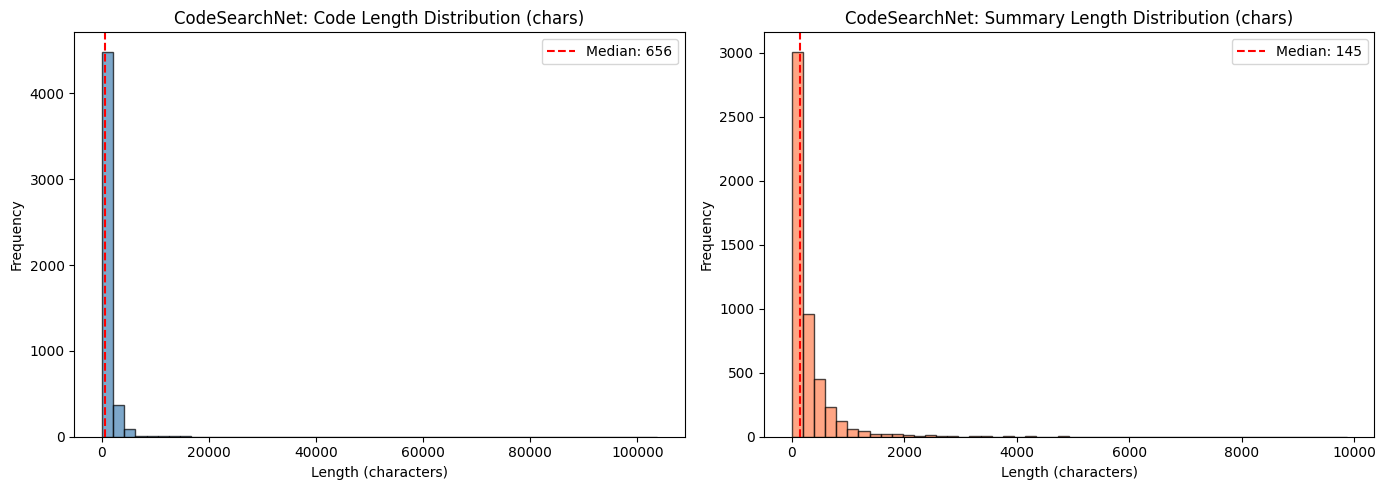

Saved: csn_data_distribution.png


In [4]:
# ============================================================
# CELL 3: LOAD & EXPLORE CodeSearchNet DATASET
# ============================================================
print("Loading CodeSearchNet dataset (Python subset)...")
csn_dataset = load_dataset("code_search_net", "python")
print(f"Dataset loaded! Train: {len(csn_dataset['train']):,}")

# Inspect
print(f"Columns: {csn_dataset['train'].column_names}")
sample = csn_dataset['train'][0]
print("\n" + "="*60)
print("SAMPLE CODE (first 500 chars):")
print("="*60)
print(sample['func_code_string'][:500])
print("\n" + "="*60)
print("SAMPLE SUMMARY:")
print("="*60)
print(sample['func_documentation_string'][:300])

# Subsample
csn_train = csn_dataset['train'].shuffle(seed=SEED).select(range(min(TRAIN_SUBSET_SIZE, len(csn_dataset['train']))))
csn_val = csn_dataset['validation'].shuffle(seed=SEED).select(range(min(VAL_SUBSET_SIZE, len(csn_dataset['validation']))))
csn_test = csn_dataset['test'].shuffle(seed=SEED).select(range(min(TEST_SUBSET_SIZE, len(csn_dataset['test']))))
print(f"\nSubset sizes - Train: {len(csn_train)}, Val: {len(csn_val)}, Test: {len(csn_test)}")

# Distribution analysis
code_lengths = [len(x['func_code_string']) for x in csn_train]
summary_lengths = [len(x['func_documentation_string']) for x in csn_train]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(code_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('CodeSearchNet: Code Length Distribution (chars)')
axes[0].set_xlabel('Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.median(code_lengths), color='red', linestyle='--', label=f'Median: {np.median(code_lengths):.0f}')
axes[0].legend()

axes[1].hist(summary_lengths, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('CodeSearchNet: Summary Length Distribution (chars)')
axes[1].set_xlabel('Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.median(summary_lengths), color='red', linestyle='--', label=f'Median: {np.median(summary_lengths):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('csn_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: csn_data_distribution.png")

Loading FunCom dataset...


README.md:   0%|          | 0.00/890 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


funcom_train.tar.gz:   0%|          | 0.00/30.7M [00:00<?, ?B/s]

funcom_val.tar.gz:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

...


Parsed first sample:
  Code (first 200): public String register(){
		Attribute attribute = new Attribute();
		attribute.put(UserAttributeKind.EMAIL,this.email);
		attribute.put(UserAttributeKind.PASSWORD,this.password);
		attribute.put(UserA
  Summary: method to respond to user register


Filter:   0%|          | 0/172394 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9196 [00:00<?, ? examples/s]

Filter:   0%|          | 0/8657 [00:00<?, ? examples/s]


Filtered empty summaries: 172394 -> 172394 (0 removed, 0.0%)

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['__key__', '__url__', 'txt', 'source', 'summary'],
        num_rows: 172394
    })
    validation: Dataset({
        features: ['__key__', '__url__', 'txt', 'source', 'summary'],
        num_rows: 9196
    })
    test: Dataset({
        features: ['__key__', '__url__', 'txt', 'source', 'summary'],
        num_rows: 8657
    })
})
Available splits: ['train', 'validation', 'test']
Using dataset's own train/validation/test splits.

Subset sizes - Train: 5000, Val: 500, Test: 500

SAMPLE CODE (first 500 chars):
public void testZoom1ActionPerformed() {
        System.out.println("testZoom1ActionPerformed");

        f.zoom1ActionPerformed(actionEvent);
 		//t.zoom1ActionPerformed(actionEvent);

 		assertEquals(1,(int) f.center.getZoom());
		//assertEquals(1,(int) t.center.getZoom());
 		assertEquals(f.zoom1, f.curZoom);

    }

SAMPLE SUMMARY:
test of zoom1

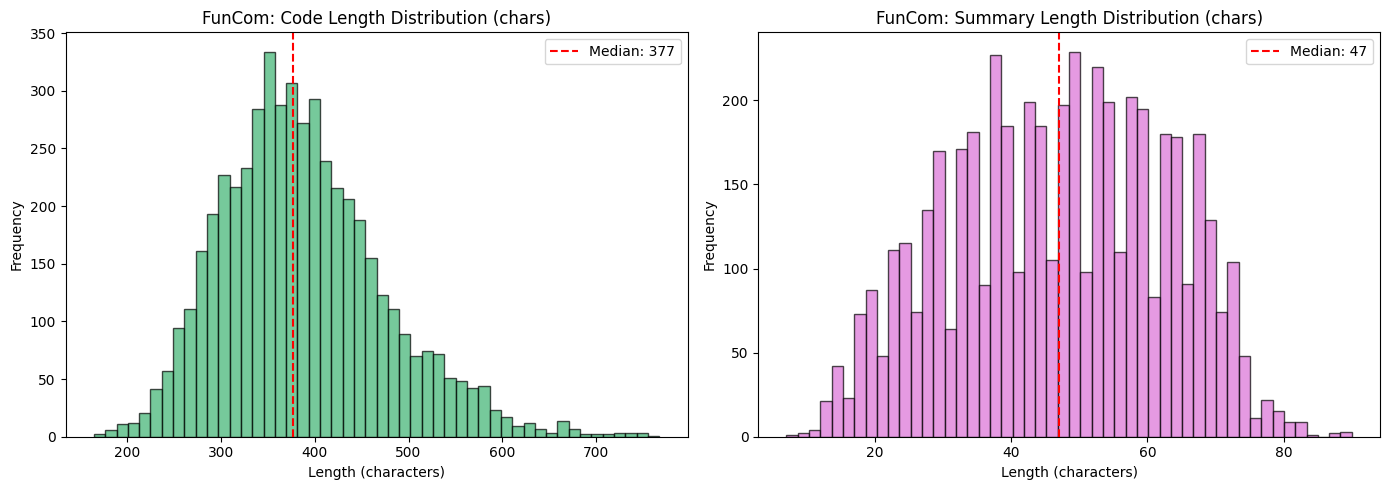

Saved: funcom_data_distribution.png


In [5]:
# ============================================================
# CELL 4: LOAD & EXPLORE FunCom DATASET (FIXED PARSING)
# ============================================================

print("Loading FunCom dataset...")

try:
    funcom_raw = load_dataset("apcl/funcom-java-long")
    print("Loaded FunCom from HuggingFace (apcl/funcom-java-long)")
    print(f"Actual columns: {funcom_raw['train'].column_names}")

    sample_txt = funcom_raw['train'][0]['txt']
    print(f"\nRaw 'txt' sample (first 500 chars):\n{sample_txt[:500]}")

    # Quick diagnostic: find the actual COM marker format
    for marker in ['COM: <s>', '\tCOM:', ' COM:', 'COMMENT:']:
        pos = sample_txt.find(marker)
        if pos >= 0:
            print(f"  Found '{marker}' at position {pos}")
            print(f"  Context: ...{repr(sample_txt[max(0,pos-20):pos+50])}...")

    # ============================================================
    # FIX: apcl/funcom-java-long confirmed format from running data:
    #   "TDAT: <code> COM: <s> comment tokens </s>"
    # The unique marker is "COM: <s>" — this combination never
    # appears in Java code naturally. We match on word-boundary
    # COM followed by the <s> sentence tag.
    # ============================================================
    def parse_funcom_txt(example):
        txt = example['txt']

        # Match "COM:" followed by optional whitespace then "<s>"
        com_match = re.search(r'\bCOM:\s*<s>', txt)
        if com_match:
            code_part = txt[:com_match.start()].strip()
            comment_section = txt[com_match.start():]

            # Strip TDAT: prefix from code
            code_part = re.sub(r'^TDAT:\s*', '', code_part).strip()

            # Extract text between <s> and </s>
            s_match = re.search(r'<s>(.*?)</s>', comment_section, re.DOTALL)
            if s_match:
                comment_part = s_match.group(1).strip()
            else:
                comment_part = ''

            example['source'] = code_part
            example['summary'] = comment_part
        else:
            # No COM: <s> marker found
            example['source'] = txt
            example['summary'] = ''

        return example

    funcom_raw = funcom_raw.map(parse_funcom_txt)
    FUNCOM_CODE_COL = "source"
    FUNCOM_SUMMARY_COL = "summary"

    # Show parsed result for first sample
    first = funcom_raw['train'][0]
    print(f"\nParsed first sample:")
    print(f"  Code (first 200): {str(first['source'])[:200]}")
    print(f"  Summary: {str(first['summary'])[:200]}")

    # Filter out samples with empty summaries
    total_before = len(funcom_raw['train'])
    funcom_raw = funcom_raw.filter(lambda x: len(str(x['summary']).strip()) > 0)
    total_after = len(funcom_raw['train'])
    print(f"\nFiltered empty summaries: {total_before} -> {total_after} "
          f"({total_before - total_after} removed, {100*(total_before-total_after)/total_before:.1f}%)")

except Exception as e:
    print(f"FunCom HF load failed: {e}")
    print("Falling back to CodeSearchNet Java subset as FunCom alternative...")
    funcom_raw = load_dataset("code_search_net", "java")
    FUNCOM_CODE_COL = "func_code_string"
    FUNCOM_SUMMARY_COL = "func_documentation_string"
    print("Loaded CodeSearchNet Java as FunCom alternative")

print(f"\nDataset structure:")
print(funcom_raw)

# Create train/val/test subsets — use existing splits if large enough
available_splits = list(funcom_raw.keys())
print(f"Available splits: {available_splits}")

if 'validation' in available_splits and 'test' in available_splits \
        and len(funcom_raw.get('validation', [])) >= VAL_SUBSET_SIZE \
        and len(funcom_raw.get('test', [])) >= TEST_SUBSET_SIZE:
    # Use the dataset's own train/val/test splits
    funcom_train = funcom_raw['train'].shuffle(seed=SEED).select(
        range(min(TRAIN_SUBSET_SIZE, len(funcom_raw['train']))))
    funcom_val = funcom_raw['validation'].shuffle(seed=SEED).select(
        range(min(VAL_SUBSET_SIZE, len(funcom_raw['validation']))))
    funcom_test = funcom_raw['test'].shuffle(seed=SEED).select(
        range(min(TEST_SUBSET_SIZE, len(funcom_raw['test']))))
    print("Using dataset's own train/validation/test splits.")
else:
    # Fallback: carve subsets from train
    funcom_full = funcom_raw['train'].shuffle(seed=SEED)
    total_available = len(funcom_full)
    tr_end = min(TRAIN_SUBSET_SIZE, total_available)
    va_end = min(tr_end + VAL_SUBSET_SIZE, total_available)
    te_end = min(va_end + TEST_SUBSET_SIZE, total_available)
    funcom_train = funcom_full.select(range(tr_end))
    funcom_val = funcom_full.select(range(tr_end, va_end))
    funcom_test = funcom_full.select(range(va_end, te_end))
    print("Carved train/val/test from the train split.")

print(f"\nSubset sizes - Train: {len(funcom_train)}, Val: {len(funcom_val)}, Test: {len(funcom_test)}")

# Verify summaries are non-empty
sample_fc = funcom_train[0]
print("\n" + "="*60)
print("SAMPLE CODE (first 500 chars):")
print("="*60)
print(str(sample_fc[FUNCOM_CODE_COL])[:500])
print("\n" + "="*60)
print("SAMPLE SUMMARY:")
print("="*60)
print(str(sample_fc[FUNCOM_SUMMARY_COL])[:300])

# Sanity check
empty_check = sum(1 for x in funcom_train if len(str(x[FUNCOM_SUMMARY_COL]).strip()) == 0)
print(f"\nEmpty summaries in train: {empty_check}/{len(funcom_train)} (should be 0)")

# Distribution analysis
fc_code_lengths = [len(str(x[FUNCOM_CODE_COL])) for x in funcom_train]
fc_summary_lengths = [len(str(x[FUNCOM_SUMMARY_COL])) for x in funcom_train]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(fc_code_lengths, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0].set_title('FunCom: Code Length Distribution (chars)')
axes[0].set_xlabel('Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.median(fc_code_lengths), color='red', linestyle='--', label=f'Median: {np.median(fc_code_lengths):.0f}')
axes[0].legend()

axes[1].hist(fc_summary_lengths, bins=50, color='orchid', edgecolor='black', alpha=0.7)
axes[1].set_title('FunCom: Summary Length Distribution (chars)')
axes[1].set_xlabel('Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.median(fc_summary_lengths), color='red', linestyle='--', label=f'Median: {np.median(fc_summary_lengths):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('funcom_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: funcom_data_distribution.png")

---
## Section 2: Tokenization & Preprocessing

We use label masking so the model learns to generate only the summary portion.
Prompt tokens are masked with -100 in the labels.

In [6]:
# ============================================================
# CELL 5: TOKENIZER SETUP & DATA PREPROCESSING
# ============================================================
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Vocab size: {tokenizer.vocab_size}")
print(f"EOS token: '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")
print(f"PAD token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")

# ---- Prompt formatting ----
PROMPT_TEMPLATE = """Below is a code snippet. Write a concise summary of what the code does.

### Code:
{code}

### Summary:
{summary}"""

def format_prompt(code, summary=""):
    return PROMPT_TEMPLATE.format(code=code.strip(), summary=summary.strip())

def format_prompt_for_inference(code):
    return f"""Below is a code snippet. Write a concise summary of what the code does.

### Code:
{code.strip()}

### Summary:
"""

# ---- Tokenization ----
def tokenize_function(examples, code_col, summary_col):
    all_input_ids = []
    all_attention_masks = []
    all_labels = []

    for code, summary in zip(examples[code_col], examples[summary_col]):
        code = str(code).strip()
        summary = str(summary).strip()

        if len(code) > 1500:
            code = code[:1500]
        if len(summary) > 300:
            summary = summary[:300]

        prompt = format_prompt_for_inference(code)
        prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)

        summary_with_eos = summary + tokenizer.eos_token
        summary_ids = tokenizer.encode(summary_with_eos, add_special_tokens=False)

        input_ids = prompt_ids + summary_ids

        if len(input_ids) > MAX_SEQ_LENGTH:
            input_ids = input_ids[:MAX_SEQ_LENGTH]

        attention_mask = [1] * len(input_ids)

        labels = [-100] * len(prompt_ids) + summary_ids
        if len(labels) > MAX_SEQ_LENGTH:
            labels = labels[:MAX_SEQ_LENGTH]

        padding_length = MAX_SEQ_LENGTH - len(input_ids)
        input_ids = input_ids + [tokenizer.pad_token_id] * padding_length
        attention_mask = attention_mask + [0] * padding_length
        labels = labels + [-100] * padding_length

        all_input_ids.append(input_ids)
        all_attention_masks.append(attention_mask)
        all_labels.append(labels)

    return {
        "input_ids": all_input_ids,
        "attention_mask": all_attention_masks,
        "labels": all_labels,
    }

# ---- Tokenize CodeSearchNet ----
print("\nTokenizing CodeSearchNet dataset...")
csn_train_tok = csn_train.map(
    lambda x: tokenize_function(x, "func_code_string", "func_documentation_string"),
    batched=True, batch_size=256, remove_columns=csn_train.column_names,
    desc="Tokenizing CSN train",
)
csn_val_tok = csn_val.map(
    lambda x: tokenize_function(x, "func_code_string", "func_documentation_string"),
    batched=True, batch_size=256, remove_columns=csn_val.column_names,
    desc="Tokenizing CSN val",
)
csn_test_tok = csn_test.map(
    lambda x: tokenize_function(x, "func_code_string", "func_documentation_string"),
    batched=True, batch_size=256, remove_columns=csn_test.column_names,
    desc="Tokenizing CSN test",
)
csn_train_tok.set_format("torch")
csn_val_tok.set_format("torch")
csn_test_tok.set_format("torch")
print(f"CSN Tokenized - Train: {len(csn_train_tok)}, Val: {len(csn_val_tok)}, Test: {len(csn_test_tok)}")

# ---- Tokenize FunCom ----
print("\nTokenizing FunCom dataset...")
fc_train_tok = funcom_train.map(
    lambda x: tokenize_function(x, FUNCOM_CODE_COL, FUNCOM_SUMMARY_COL),
    batched=True, batch_size=256, remove_columns=funcom_train.column_names,
    desc="Tokenizing FunCom train",
)
fc_val_tok = funcom_val.map(
    lambda x: tokenize_function(x, FUNCOM_CODE_COL, FUNCOM_SUMMARY_COL),
    batched=True, batch_size=256, remove_columns=funcom_val.column_names,
    desc="Tokenizing FunCom val",
)
fc_test_tok = funcom_test.map(
    lambda x: tokenize_function(x, FUNCOM_CODE_COL, FUNCOM_SUMMARY_COL),
    batched=True, batch_size=256, remove_columns=funcom_test.column_names,
    desc="Tokenizing FunCom test",
)
fc_train_tok.set_format("torch")
fc_val_tok.set_format("torch")
fc_test_tok.set_format("torch")
print(f"FunCom Tokenized - Train: {len(fc_train_tok)}, Val: {len(fc_val_tok)}, Test: {len(fc_test_tok)}")

sample_ids = csn_train_tok[0]['input_ids']
non_pad = (sample_ids != tokenizer.pad_token_id).sum().item()
print(f"\nSample token length (non-pad): {non_pad}/{MAX_SEQ_LENGTH}")
print("Tokenization complete!")

Loading tokenizer...


config.json:   0%|          | 0.00/602 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

...

CSN Tokenized - Train: 5000, Val: 500, Test: 500

Tokenizing FunCom dataset...


Tokenizing FunCom train:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing FunCom val:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing FunCom test:   0%|          | 0/500 [00:00<?, ? examples/s]

FunCom Tokenized - Train: 5000, Val: 500, Test: 500

Sample token length (non-pad): 386/512
Tokenization complete!


---
## Section 3: Model Loading (QLoRA)

We load the model with 4-bit NF4 quantization and apply LoRA adapters:
- **LoRA rank:** 16, **alpha:** 32, **dropout:** 0.05
- **Target modules:** q, k, v, o projections + gate, up, down MLP layers
- **Trainable parameters:** ~25M (~0.89% of total)

In [7]:
# ============================================================
# CELL 6: LOAD MODEL WITH QLoRA
# ============================================================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Loading model with 4-bit quantization...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)

model = prepare_model_for_kbit_training(model)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, lora_config)

trainable, total = model.get_nb_trainable_parameters()
print(f"\nModel loaded!")
print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Trainable %: {100 * trainable / total:.2f}%")
print(f"Memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")
print(f"\nArchitecture: {model.config.num_hidden_layers} layers, "
      f"hidden={model.config.hidden_size}, heads={model.config.num_attention_heads}")

Loading model with 4-bit quantization...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


Model loaded!
Total parameters: 2,820,477,952
Trainable parameters: 25,034,752
Trainable %: 0.89%
Memory footprint: 2.40 GB

Architecture: 32 layers, hidden=2560, heads=32


---
## Section 4: Fine-tuning on CodeSearchNet

Training configuration: 3 epochs, LR=2e-4 cosine, BS=16 (4×4 grad accum), early stopping patience 3.

In [8]:
# ============================================================
# CELL 7: FINE-TUNE ON CodeSearchNet
# ============================================================
CSN_OUTPUT_DIR = "./results_csn"

csn_training_args = TrainingArguments(
    output_dir=CSN_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.01,
    optim="paged_adamw_8bit",
    fp16=True,
    bf16=False,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=SEED,
    gradient_checkpointing=True,
    max_grad_norm=0.3,
)

csn_trainer = Trainer(
    model=model,
    args=csn_training_args,
    train_dataset=csn_train_tok,
    eval_dataset=csn_val_tok,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Starting fine-tuning on CodeSearchNet...")
print(f"Total training steps: ~{len(csn_train_tok) // (4 * 4) * 3}")
csn_train_result = csn_trainer.train()

print("\n" + "="*50)
print("CodeSearchNet Training Complete!")
print(f"Training loss: {csn_train_result.training_loss:.4f}")
print(f"Training time: {csn_train_result.metrics['train_runtime']:.1f}s")

csn_trainer.save_model(f"{CSN_OUTPUT_DIR}/final_model")
print(f"Model saved to {CSN_OUTPUT_DIR}/final_model")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting fine-tuning on CodeSearchNet...
Total training steps: ~936


Step,Training Loss,Validation Loss
100,0.032786,0.035653
200,0.030707,0.034958
300,0.033069,0.034073
400,0.018394,0.033667
500,0.014690,0.038359
600,0.018256,0.029783
700,0.007964,0.039332
800,0.005052,0.037152
900,0.007562,0.039185



CodeSearchNet Training Complete!
Training loss: 0.0252
Training time: 2865.5s
Model saved to ./results_csn/final_model


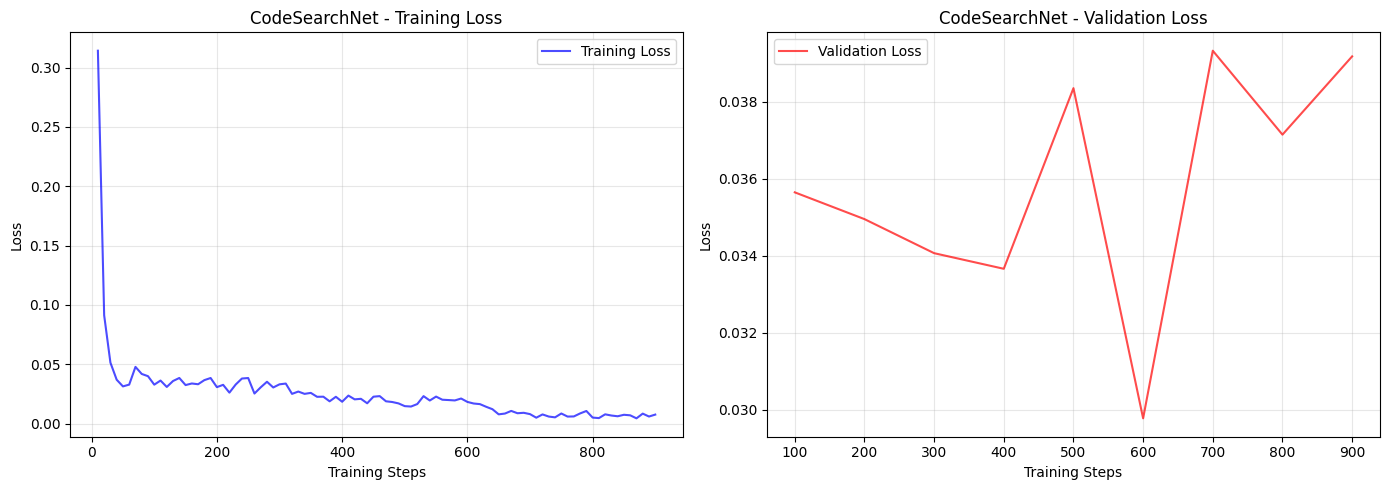

Saved: csn_training_curves.png

Best validation loss: 0.0298
Final validation loss: 0.0392


In [9]:
# ============================================================
# CELL 8: PLOT CodeSearchNet TRAINING CURVES
# ============================================================
csn_log_history = csn_trainer.state.log_history
csn_train_losses = [(x['step'], x['loss']) for x in csn_log_history if 'loss' in x]
csn_eval_losses = [(x['step'], x['eval_loss']) for x in csn_log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if csn_train_losses:
    steps, losses = zip(*csn_train_losses)
    axes[0].plot(steps, losses, 'b-', alpha=0.7, linewidth=1.5, label='Training Loss')
    axes[0].set_title('CodeSearchNet - Training Loss')
    axes[0].set_xlabel('Training Steps')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

if csn_eval_losses:
    steps, losses = zip(*csn_eval_losses)
    axes[1].plot(steps, losses, 'r-', alpha=0.7, linewidth=1.5, label='Validation Loss')
    axes[1].set_title('CodeSearchNet - Validation Loss')
    axes[1].set_xlabel('Training Steps')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('csn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: csn_training_curves.png")

if csn_eval_losses:
    print(f"\nBest validation loss: {min(l for _, l in csn_eval_losses):.4f}")
    print(f"Final validation loss: {csn_eval_losses[-1][1]:.4f}")

---
## Section 5: Fine-tuning on FunCom Dataset

We reload the base model with fresh LoRA adapters to ensure a fair comparison.

In [10]:
# ============================================================
# CELL 9: RELOAD MODEL & FINE-TUNE ON FunCom
# ============================================================
del csn_trainer
gc.collect()
torch.cuda.empty_cache()

print("Reloading model with fresh LoRA adapters for FunCom training...")
model_fc = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
model_fc = prepare_model_for_kbit_training(model_fc)
model_fc.config.use_cache = False
model_fc = get_peft_model(model_fc, lora_config)

trainable, total = model_fc.get_nb_trainable_parameters()
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

FC_OUTPUT_DIR = "./results_funcom"

fc_training_args = TrainingArguments(
    output_dir=FC_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.01,
    optim="paged_adamw_8bit",
    fp16=True,
    bf16=False,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=SEED,
    gradient_checkpointing=True,
    max_grad_norm=0.3,
)

fc_trainer = Trainer(
    model=model_fc,
    args=fc_training_args,
    train_dataset=fc_train_tok,
    eval_dataset=fc_val_tok,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("\nStarting fine-tuning on FunCom...")
print(f"Total training steps: ~{len(fc_train_tok) // (4 * 4) * 3}")
fc_train_result = fc_trainer.train()

print("\n" + "="*50)
print("FunCom Training Complete!")
print(f"Training loss: {fc_train_result.training_loss:.4f}")
print(f"Training time: {fc_train_result.metrics['train_runtime']:.1f}s")

fc_trainer.save_model(f"{FC_OUTPUT_DIR}/final_model")
print(f"Model saved to {FC_OUTPUT_DIR}/final_model")

Reloading model with fresh LoRA adapters for FunCom training...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainable parameters: 25,034,752 / 2,820,477,952 (0.89%)

Starting fine-tuning on FunCom...
Total training steps: ~936


Step,Training Loss,Validation Loss
100,2.068873,1.965299
200,1.897017,1.907584
300,1.713431,1.902301
400,1.233587,2.102143
500,1.222751,2.098714
600,1.160320,2.086702



FunCom Training Complete!
Training loss: 1.6092
Training time: 1909.8s
Model saved to ./results_funcom/final_model


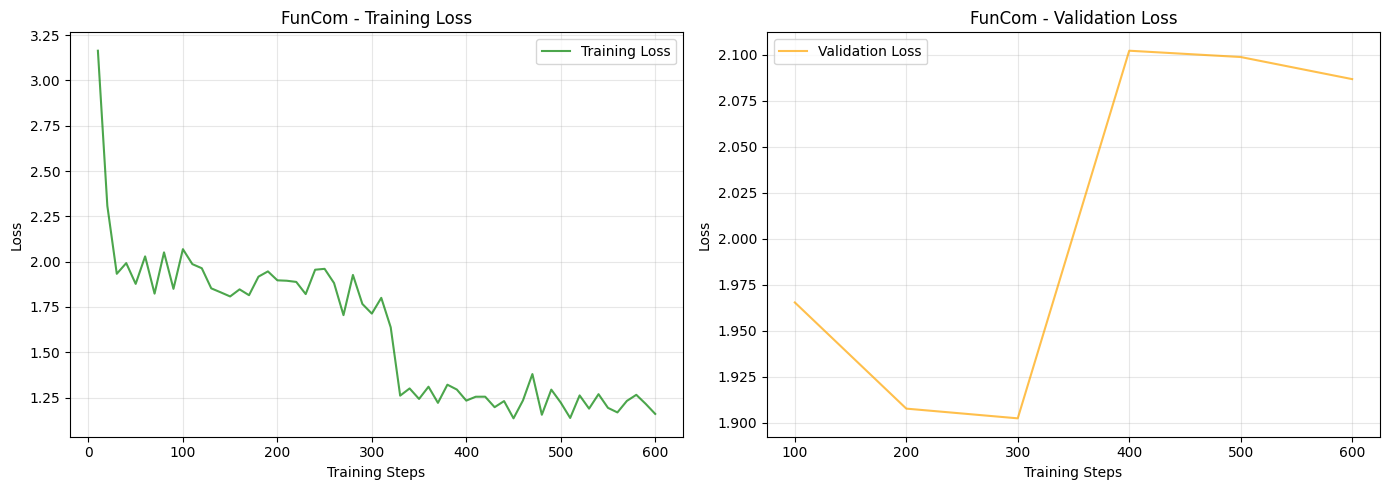

Saved: funcom_training_curves.png

Best validation loss: 1.9023
Final validation loss: 2.0867


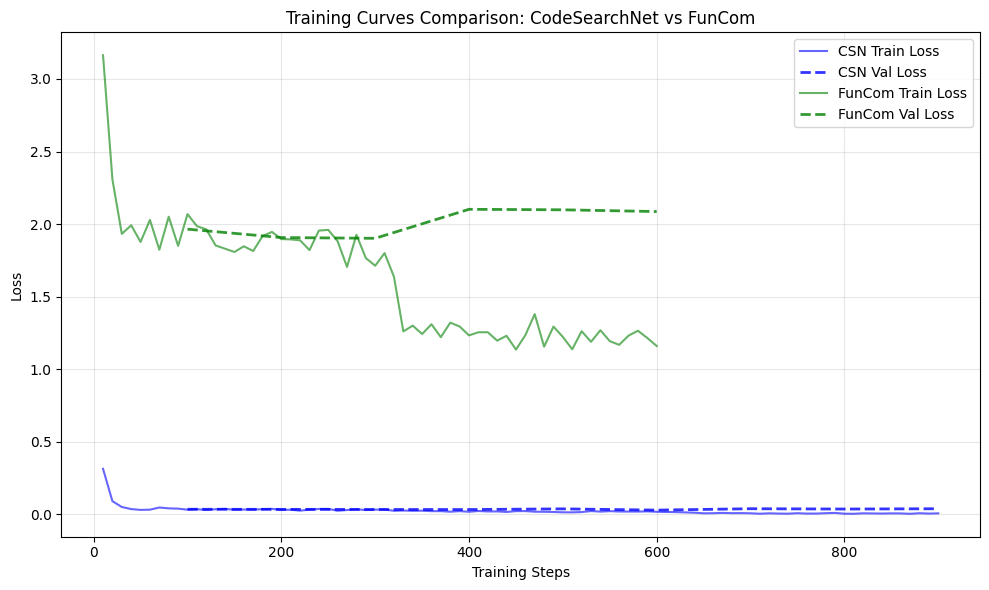

Saved: combined_training_curves.png


In [11]:
# ============================================================
# CELL 10: PLOT FunCom TRAINING CURVES + COMBINED
# ============================================================
fc_log_history = fc_trainer.state.log_history
fc_train_losses = [(x['step'], x['loss']) for x in fc_log_history if 'loss' in x]
fc_eval_losses = [(x['step'], x['eval_loss']) for x in fc_log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if fc_train_losses:
    steps, losses = zip(*fc_train_losses)
    axes[0].plot(steps, losses, 'g-', alpha=0.7, linewidth=1.5, label='Training Loss')
    axes[0].set_title('FunCom - Training Loss')
    axes[0].set_xlabel('Training Steps')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

if fc_eval_losses:
    steps, losses = zip(*fc_eval_losses)
    axes[1].plot(steps, losses, 'orange', alpha=0.7, linewidth=1.5, label='Validation Loss')
    axes[1].set_title('FunCom - Validation Loss')
    axes[1].set_xlabel('Training Steps')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('funcom_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: funcom_training_curves.png")

if fc_eval_losses:
    print(f"\nBest validation loss: {min(l for _, l in fc_eval_losses):.4f}")
    print(f"Final validation loss: {fc_eval_losses[-1][1]:.4f}")

# Combined comparison plot
fig, ax = plt.subplots(figsize=(10, 6))
if csn_train_losses:
    steps, losses = zip(*csn_train_losses)
    ax.plot(steps, losses, 'b-', alpha=0.6, label='CSN Train Loss')
if csn_eval_losses:
    steps, losses = zip(*csn_eval_losses)
    ax.plot(steps, losses, 'b--', alpha=0.8, linewidth=2, label='CSN Val Loss')
if fc_train_losses:
    steps, losses = zip(*fc_train_losses)
    ax.plot(steps, losses, 'g-', alpha=0.6, label='FunCom Train Loss')
if fc_eval_losses:
    steps, losses = zip(*fc_eval_losses)
    ax.plot(steps, losses, 'g--', alpha=0.8, linewidth=2, label='FunCom Val Loss')
ax.set_title('Training Curves Comparison: CodeSearchNet vs FunCom')
ax.set_xlabel('Training Steps')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('combined_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: combined_training_curves.png")

---
## Section 6: Evaluation

### Metrics
- **BLEU:** n-gram precision (0–100)
- **ROUGE-1 / ROUGE-2 / ROUGE-L:** Recall-oriented unigram, bigram, and LCS overlap
- **METEOR:** Considers synonyms and stemming

We evaluate on 100 test samples with greedy decoding.

In [12]:
# ============================================================
# CELL 11: EVALUATION UTILITIES
# ============================================================
bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")

nltk.download('wordnet', quiet=True)
meteor_metric = evaluate.load("meteor")

def generate_summary(model_to_eval, code_text, max_new_tokens=128):
    prompt = format_prompt_for_inference(code_text)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,
                       max_length=MAX_SEQ_LENGTH - max_new_tokens)
    inputs = {k: v.to(model_to_eval.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model_to_eval.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
    summary = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    if '\n\n' in summary:
        summary = summary.split('\n\n')[0]

    return summary

def evaluate_model(model_to_eval, test_dataset_raw, code_col, summary_col, num_samples=100):
    model_to_eval.eval()
    predictions = []
    references = []

    print(f"Generating summaries for {num_samples} test samples...")
    for i in range(min(num_samples, len(test_dataset_raw))):
        if i % 20 == 0:
            print(f"  Progress: {i}/{num_samples}")

        code = str(test_dataset_raw[i][code_col])
        ref_summary = str(test_dataset_raw[i][summary_col]).strip()

        pred_summary = generate_summary(model_to_eval, code)
        predictions.append(pred_summary)
        references.append(ref_summary)

    print("\nComputing metrics...")
    bleu_result = bleu_metric.compute(predictions=predictions,
                                      references=[[r] for r in references])
    rouge_result = rouge_metric.compute(predictions=predictions,
                                        references=references)
    meteor_result = meteor_metric.compute(predictions=predictions,
                                          references=references)

    metrics = {
        "BLEU": bleu_result['score'],
        "ROUGE-1": rouge_result['rouge1'] * 100,
        "ROUGE-2": rouge_result['rouge2'] * 100,
        "ROUGE-L": rouge_result['rougeL'] * 100,
        "METEOR": meteor_result['meteor'] * 100,
    }

    return metrics, predictions, references

print("Evaluation utilities ready!")

Evaluation utilities ready!


[nltk_data] Downloading package wordnet to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...


In [13]:
# ============================================================
# CELL 12: EVALUATE ON CodeSearchNet
# ============================================================
print("Loading best CodeSearchNet model...")
csn_eval_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map="auto", trust_remote_code=True, attn_implementation="eager",
)
csn_eval_model = PeftModel.from_pretrained(csn_eval_model, f"{CSN_OUTPUT_DIR}/final_model")
csn_eval_model.eval()

print("Evaluating on CodeSearchNet test set...")
csn_metrics, csn_preds, csn_refs = evaluate_model(
    csn_eval_model, csn_test, "func_code_string", "func_documentation_string", num_samples=100
)

print("\n" + "="*60)
print("CodeSearchNet Evaluation Results:")
print("="*60)
for metric, value in csn_metrics.items():
    print(f"  {metric}: {value:.2f}")

print("\n" + "="*60)
print("SAMPLE PREDICTIONS (CodeSearchNet):")
print("="*60)
for i in range(min(5, len(csn_preds))):
    print(f"\n--- Example {i+1} ---")
    print(f"Reference:  {csn_refs[i][:200]}")
    print(f"Predicted:  {csn_preds[i][:200]}")

del csn_eval_model
gc.collect()
torch.cuda.empty_cache()

Loading best CodeSearchNet model...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Evaluating on CodeSearchNet test set...
Generating summaries for 100 test samples...
  Progress: 0/100
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100

Computing metrics...

CodeSearchNet Evaluation Results:
  BLEU: 7.42
  ROUGE-1: 60.30
  ROUGE-2: 56.56
  ROUGE-L: 59.60
  METEOR: 51.96

SAMPLE PREDICTIONS (CodeSearchNet):

--- Example 1 ---
Reference:  Read symbol and extra from stream and explain what happens.
        Returns the value of the symbol
        >>> olleke.pos = 0
        >>> l = Layout(olleke)
        >>> l.verboseRead(WindowSizeAlphab
Predicted:  #TODO 1: verbosity level, e.g. show only codes and maps in header
        return '{:04x} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {:s} {

--- Example 2 ---
Reference:  Removes all fronts from `fronts` which are strictly smaller than
    `size` consecutive frequencies in length.
Predicted:  Removes all fronts from `fronts` which are stric

In [ ]:
# ============================================================
# CELL 13: EVALUATE ON FunCom
# ============================================================
print("Loading best FunCom model...")
fc_eval_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map="auto", trust_remote_code=True, attn_implementation="eager",
)
fc_eval_model = PeftModel.from_pretrained(fc_eval_model, f"{FC_OUTPUT_DIR}/final_model")
fc_eval_model.eval()

print("Evaluating on FunCom test set...")
fc_metrics, fc_preds, fc_refs = evaluate_model(
    fc_eval_model, funcom_test, FUNCOM_CODE_COL, FUNCOM_SUMMARY_COL, num_samples=100
)

print("\n" + "="*60)
print("FunCom Evaluation Results:")
print("="*60)
for metric, value in fc_metrics.items():
    print(f"  {metric}: {value:.2f}")

print("\n" + "="*60)
print("SAMPLE PREDICTIONS (FunCom):")
print("="*60)
for i in range(min(5, len(fc_preds))):
    print(f"\n--- Example {i+1} ---")
    print(f"Reference:  {fc_refs[i][:200]}")
    print(f"Predicted:  {fc_preds[i][:200]}")

del fc_eval_model
gc.collect()
torch.cuda.empty_cache()

Loading best FunCom model...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Evaluating on FunCom test set...
Generating summaries for 100 test samples...
  Progress: 0/100
  Progress: 20/100
  Progress: 40/100


In [ ]:
# ============================================================
# CELL 14: RESULTS COMPARISON TABLE & VISUALIZATION
# ============================================================
results_df = pd.DataFrame({
    'Metric': list(csn_metrics.keys()),
    'CodeSearchNet': [f"{v:.2f}" for v in csn_metrics.values()],
    'FunCom': [f"{v:.2f}" for v in fc_metrics.values()],
})

print("="*60)
print("RESULTS COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(csn_metrics))
width = 0.35

bars1 = ax.bar(x - width/2, list(csn_metrics.values()), width,
               label='CodeSearchNet', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, list(fc_metrics.values()), width,
               label='FunCom', color='coral', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Evaluation Metrics Comparison: CodeSearchNet vs FunCom')
ax.set_xticks(x)
ax.set_xticklabels(list(csn_metrics.keys()))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: evaluation_comparison.png")

---
## Section 7: Hyperparameter Sweep

We sweep over learning rate, LoRA rank, and LoRA dropout on the **full training set**
(5,000 samples) for 1 epoch per configuration. This ensures statistically meaningful
comparisons as recommended for large-scale hyperparameter analysis.

| Config | LR | Rank | Dropout | Notes |
|---|---|---|---|---|
| lr=1e-4 | 1e-4 | 16 | 0.05 | Lower LR |
| lr=5e-4 | 5e-4 | 16 | 0.05 | Higher LR |
| rank=8 | 2e-4 | 8 | 0.05 | Fewer params |
| rank=32 | 2e-4 | 32 | 0.05 | More params |
| dropout=0.0 | 2e-4 | 16 | 0.0 | No regularization |
| dropout=0.1 | 2e-4 | 16 | 0.1 | More regularization |

In [16]:
# ============================================================
# CELL 15: HYPERPARAMETER EXPERIMENTS
# Uses full training set (5K samples) for 1 epoch per config.
# Estimated: ~70 min on L40S, ~45 min on A100
# ============================================================

hyperparameter_configs = [
    {"name": "lr=1e-4", "lr": 1e-4, "lora_r": 16, "lora_dropout": 0.05},
    {"name": "lr=5e-4", "lr": 5e-4, "lora_r": 16, "lora_dropout": 0.05},
    {"name": "rank=8", "lr": 2e-4, "lora_r": 8, "lora_dropout": 0.05},
    {"name": "rank=32", "lr": 2e-4, "lora_r": 32, "lora_dropout": 0.05},
    {"name": "dropout=0.0", "lr": 2e-4, "lora_r": 16, "lora_dropout": 0.0},
    {"name": "dropout=0.1", "lr": 2e-4, "lora_r": 16, "lora_dropout": 0.1},
]

# Use FULL training set for HP sweep (as recommended for large-scale analysis)
hp_train = csn_train_tok
hp_val = csn_val_tok

print(f"HP sweep: {len(hp_train)} train samples, {len(hp_val)} val samples")
print(f"Steps per config: ~{len(hp_train) // (4 * 4)} (1 epoch)")
print(f"Total configs: {len(hyperparameter_configs)}")

hp_results = []

for i, config in enumerate(hyperparameter_configs):
    print(f"\n{'='*60}")
    print(f"Experiment {i+1}/{len(hyperparameter_configs)}: {config['name']}")
    print(f"{'='*60}")

    gc.collect()
    torch.cuda.empty_cache()

    hp_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb_config,
        device_map="auto", trust_remote_code=True, attn_implementation="eager",
    )
    hp_model = prepare_model_for_kbit_training(hp_model)
    hp_model.config.use_cache = False

    hp_lora_config = LoraConfig(
        r=config['lora_r'],
        lora_alpha=config['lora_r'] * 2,
        lora_dropout=config['lora_dropout'],
        bias="none",
        task_type=TaskType.CAUSAL_LM,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
    )
    hp_model = get_peft_model(hp_model, hp_lora_config)

    trainable, total = hp_model.get_nb_trainable_parameters()
    print(f"  Trainable params: {trainable:,} ({100*trainable/total:.2f}%)")

    hp_args = TrainingArguments(
        output_dir=f"./hp_exp_{i}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=config['lr'],
        lr_scheduler_type="cosine",
        warmup_ratio=0.03,
        weight_decay=0.01,
        optim="paged_adamw_8bit",
        fp16=True,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        seed=SEED,
        gradient_checkpointing=True,
        max_grad_norm=0.3,
    )

    hp_trainer = Trainer(
        model=hp_model,
        args=hp_args,
        train_dataset=hp_train,
        eval_dataset=hp_val,
    )

    result = hp_trainer.train()

    # Extract eval loss from training log history
    eval_loss = None
    for log_entry in reversed(hp_trainer.state.log_history):
        if 'eval_loss' in log_entry:
            eval_loss = log_entry['eval_loss']
            break

    if eval_loss is None:
        eval_result = hp_trainer.evaluate()
        eval_loss = eval_result['eval_loss']

    hp_results.append({
        "config": config['name'],
        "train_loss": result.training_loss,
        "eval_loss": eval_loss,
        "lr": config['lr'],
        "lora_r": config['lora_r'],
        "lora_dropout": config['lora_dropout'],
        "trainable_params": trainable,
    })

    print(f"  Train loss: {result.training_loss:.4f}")
    print(f"  Eval loss: {eval_loss:.4f}")

    del hp_model, hp_trainer
    gc.collect()
    torch.cuda.empty_cache()

hp_df = pd.DataFrame(hp_results)
print("\n" + "="*60)
print("HYPERPARAMETER EXPERIMENT RESULTS")
print("="*60)
print(hp_df.to_string(index=False))

  Train loss: 0.0430
  Eval loss: 0.0328

Experiment 2/6: lr=5e-4


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Trainable params: 25,034,752 (0.89%)


Epoch,Training Loss,Validation Loss
1,0.031669,0.032577


...

Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Trainable params: 25,034,752 (0.89%)


Epoch,Training Loss,Validation Loss
1,0.029309,0.030343


  Train loss: 0.0417
  Eval loss: 0.0303

HYPERPARAMETER EXPERIMENT RESULTS
     config  train_loss  eval_loss     lr  lora_r  lora_dropout  trainable_params
    lr=1e-4    0.043008   0.032778 0.0001      16          0.05          25034752
    lr=5e-4    0.045376   0.032577 0.0005      16          0.05          25034752
     rank=8    0.042116   0.031709 0.0002       8          0.05          12517376
    rank=32    0.040631   0.031299 0.0002      32          0.05          50069504
dropout=0.0    0.041977   0.029881 0.0002      16          0.00          25034752
dropout=0.1    0.041712   0.030343 0.0002      16          0.10          25034752


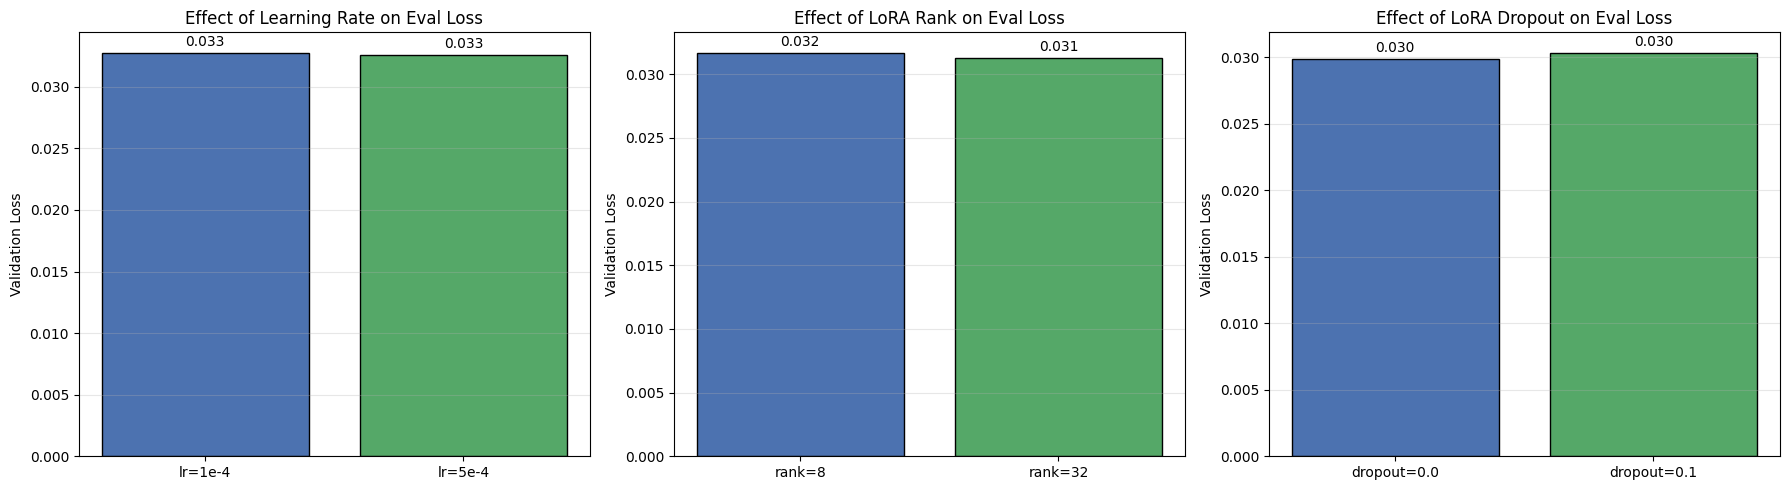

Saved: hyperparameter_experiments.png


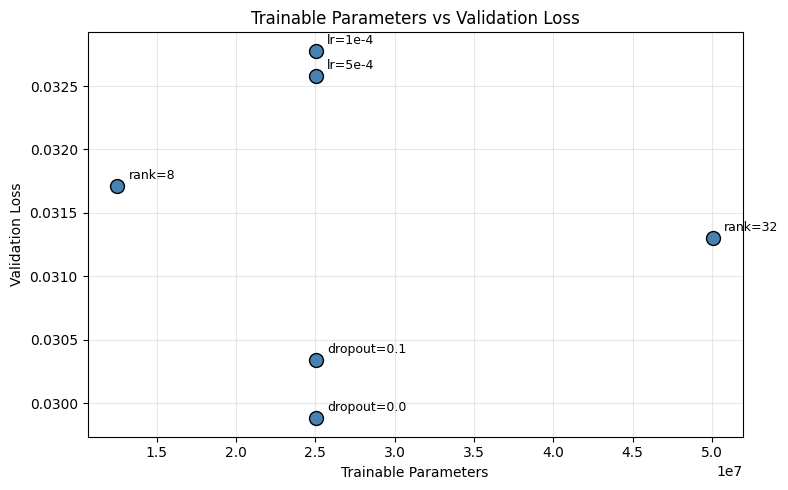

Saved: params_vs_loss.png


In [17]:
# ============================================================
# CELL 16: PLOT HYPERPARAMETER RESULTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lr_subset = hp_df[hp_df['config'].str.startswith('lr')]
if len(lr_subset) > 0:
    axes[0].bar(lr_subset['config'], lr_subset['eval_loss'],
                color=['#4C72B0', '#55A868', '#C44E52'][:len(lr_subset)], edgecolor='black')
    axes[0].set_title('Effect of Learning Rate on Eval Loss')
    axes[0].set_ylabel('Validation Loss')
    axes[0].grid(True, alpha=0.3, axis='y')
    for j, (_, row) in enumerate(lr_subset.iterrows()):
        axes[0].annotate(f'{row["eval_loss"]:.3f}', (j, row['eval_loss']),
                        textcoords="offset points", xytext=(0,5), ha='center', fontsize=10)

rank_subset = hp_df[hp_df['config'].str.startswith('rank')]
if len(rank_subset) > 0:
    axes[1].bar(rank_subset['config'], rank_subset['eval_loss'],
                color=['#4C72B0', '#55A868'], edgecolor='black')
    axes[1].set_title('Effect of LoRA Rank on Eval Loss')
    axes[1].set_ylabel('Validation Loss')
    axes[1].grid(True, alpha=0.3, axis='y')
    for j, (_, row) in enumerate(rank_subset.iterrows()):
        axes[1].annotate(f'{row["eval_loss"]:.3f}', (j, row['eval_loss']),
                        textcoords="offset points", xytext=(0,5), ha='center', fontsize=10)

drop_subset = hp_df[hp_df['config'].str.startswith('dropout')]
if len(drop_subset) > 0:
    axes[2].bar(drop_subset['config'], drop_subset['eval_loss'],
                color=['#4C72B0', '#55A868'], edgecolor='black')
    axes[2].set_title('Effect of LoRA Dropout on Eval Loss')
    axes[2].set_ylabel('Validation Loss')
    axes[2].grid(True, alpha=0.3, axis='y')
    for j, (_, row) in enumerate(drop_subset.iterrows()):
        axes[2].annotate(f'{row["eval_loss"]:.3f}', (j, row['eval_loss']),
                        textcoords="offset points", xytext=(0,5), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('hyperparameter_experiments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hyperparameter_experiments.png")

# Trainable params vs eval loss
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(hp_df['trainable_params'], hp_df['eval_loss'], s=100,
           c='steelblue', edgecolor='black', zorder=5)
for _, row in hp_df.iterrows():
    ax.annotate(row['config'], (row['trainable_params'], row['eval_loss']),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel('Trainable Parameters')
ax.set_ylabel('Validation Loss')
ax.set_title('Trainable Parameters vs Validation Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('params_vs_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: params_vs_loss.png")

---
## Section 8: Mechanistic Interpretability

We perform several analyses to understand how the model processes code:
1. **Attention Pattern Visualization** — Which tokens does the model attend to?
2. **Attention Entropy** — How focused/diffuse is the attention?
3. **Hidden State Trajectory (PCA)** — How do representations evolve across layers?
4. **Cosine Similarity** — Where does the most transformation occur?
5. **Head Specialization** — Do heads specialize on token categories?
6. **Gradient-Based Token Attribution** — Which input tokens matter most?
7. **LoRA Weight Analysis** — Which layers adapted the most?

Loading fine-tuned model for interpretability analysis...


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Extracting attention patterns...
Layers: 32, Heads: 32, Seq len: 164


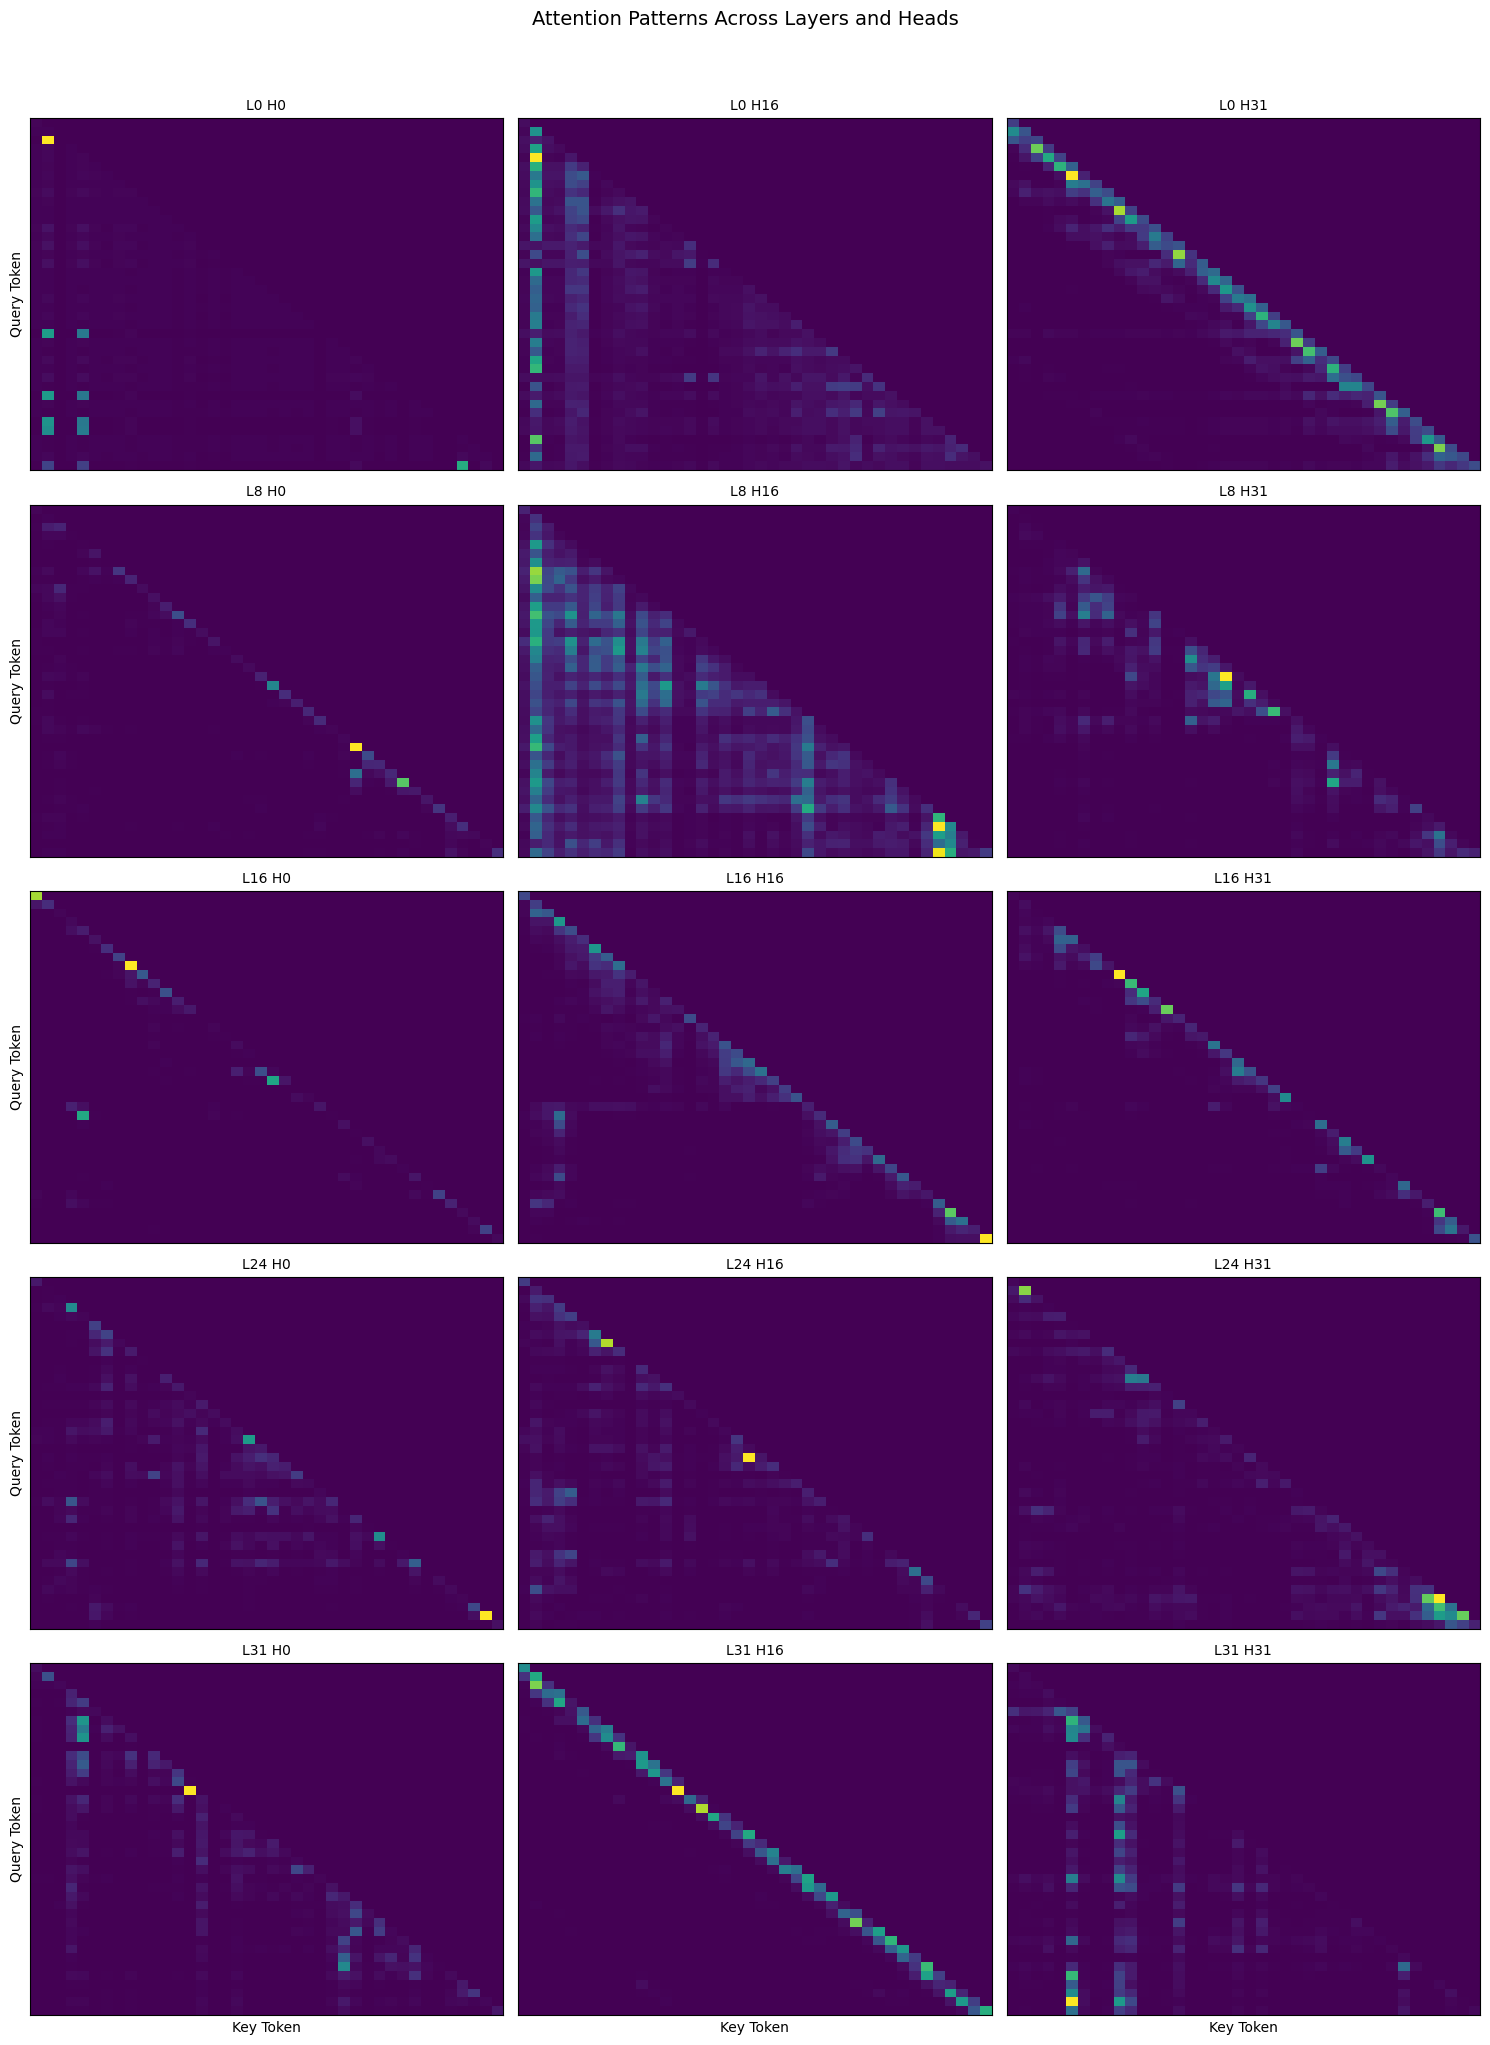

Saved: attention_patterns.png

Attention Entropy Analysis:
  Layer  0: Avg entropy = 3.8655
  Layer  8: Avg entropy = 1.6592
  Layer 16: Avg entropy = 1.8822
  Layer 24: Avg entropy = 1.4042


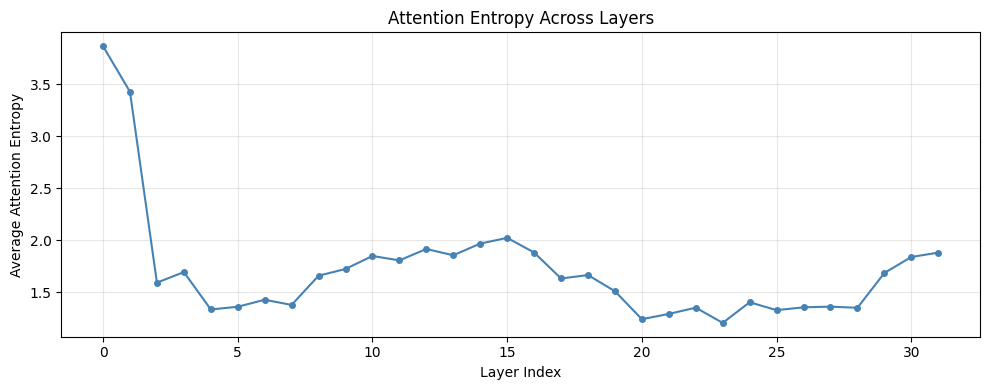

Saved: attention_entropy_by_layer.png


In [18]:
# ============================================================
# CELL 17: ATTENTION PATTERN VISUALIZATION
# ============================================================
from sklearn.decomposition import PCA

print("Loading fine-tuned model for interpretability analysis...")
interp_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map="auto", trust_remote_code=True, attn_implementation="eager",
)
interp_model = PeftModel.from_pretrained(interp_model, f"{CSN_OUTPUT_DIR}/final_model")
interp_model.eval()

sample_code = str(csn_test[0]['func_code_string'])
if len(sample_code) > 500:
    sample_code = sample_code[:500]

prompt = format_prompt_for_inference(sample_code)
inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
inputs = {k: v.to(interp_model.device) for k, v in inputs.items()}

print("Extracting attention patterns...")
with torch.no_grad():
    outputs = interp_model(**inputs, output_attentions=True)

attentions = outputs.attentions
num_layers = len(attentions)
num_heads = attentions[0].shape[1]
seq_len = attentions[0].shape[-1]

print(f"Layers: {num_layers}, Heads: {num_heads}, Seq len: {seq_len}")

input_ids = inputs['input_ids'][0].cpu().tolist()
tokens = [tokenizer.decode([tid]).replace('\n', '\\n').replace(' ', '_')[:10] for tid in input_ids]

layers_to_show = [0, num_layers // 4, num_layers // 2, 3 * num_layers // 4, num_layers - 1]
heads_to_show = [0, num_heads // 2, num_heads - 1]

N_TOKENS = min(40, seq_len)
token_labels = tokens[-N_TOKENS:]

fig, axes = plt.subplots(len(layers_to_show), len(heads_to_show),
                         figsize=(5 * len(heads_to_show), 4 * len(layers_to_show)))

for i, layer_idx in enumerate(layers_to_show):
    for j, head_idx in enumerate(heads_to_show):
        attn = attentions[layer_idx][0, head_idx, -N_TOKENS:, -N_TOKENS:].float().cpu().numpy()
        ax = axes[i, j] if len(layers_to_show) > 1 else axes[j]
        ax.imshow(attn, cmap='viridis', aspect='auto')
        ax.set_title(f'L{layer_idx} H{head_idx}', fontsize=10)
        if j == 0:
            ax.set_ylabel('Query Token')
        if i == len(layers_to_show) - 1:
            ax.set_xlabel('Key Token')
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Attention Patterns Across Layers and Heads', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('attention_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: attention_patterns.png")

# Attention entropy per layer
print("\nAttention Entropy Analysis:")
layer_entropies = []
for layer_idx in range(num_layers):
    attn = attentions[layer_idx][0].float().cpu()
    eps = 1e-10
    entropy = -(attn * torch.log(attn + eps)).sum(dim=-1).mean().item()
    layer_entropies.append(entropy)
    if layer_idx % 8 == 0:
        print(f"  Layer {layer_idx:2d}: Avg entropy = {entropy:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(num_layers), layer_entropies, 'o-', color='steelblue', markersize=4)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Average Attention Entropy')
ax.set_title('Attention Entropy Across Layers')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('attention_entropy_by_layer.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: attention_entropy_by_layer.png")

Extracting hidden states across layers...
Hidden state layers: 33 (including embedding)


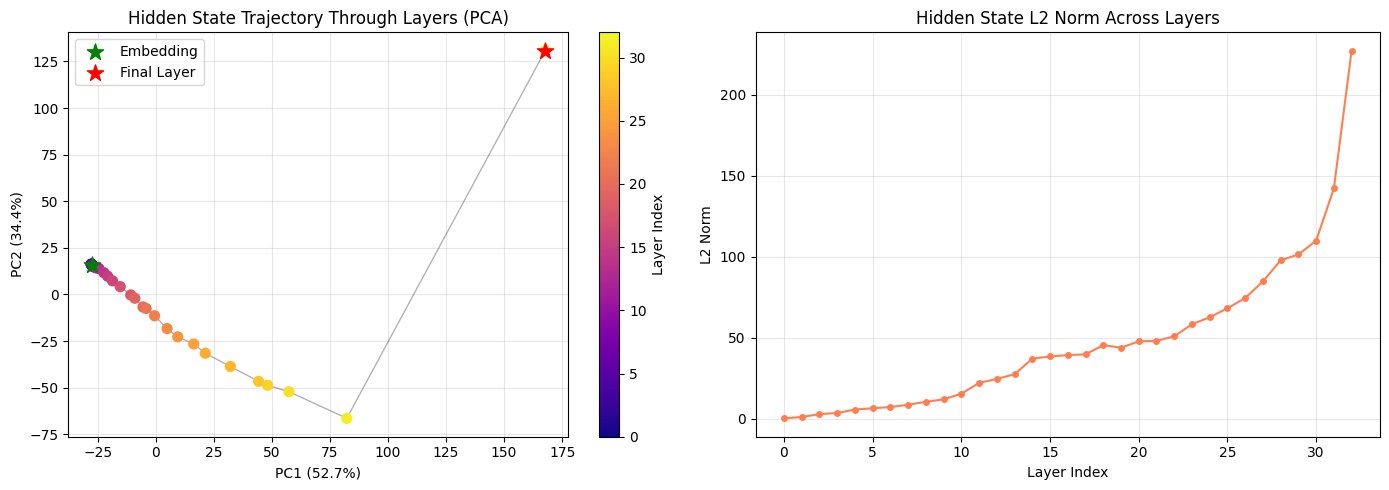

Saved: hidden_state_analysis.png

Cosine Similarity Between Adjacent Layers:
  Layer 7 -> 8: 0.8824
  Layer 15 -> 16: 0.9194
  Layer 23 -> 24: 0.9754
  Layer 31 -> 32: 0.3632


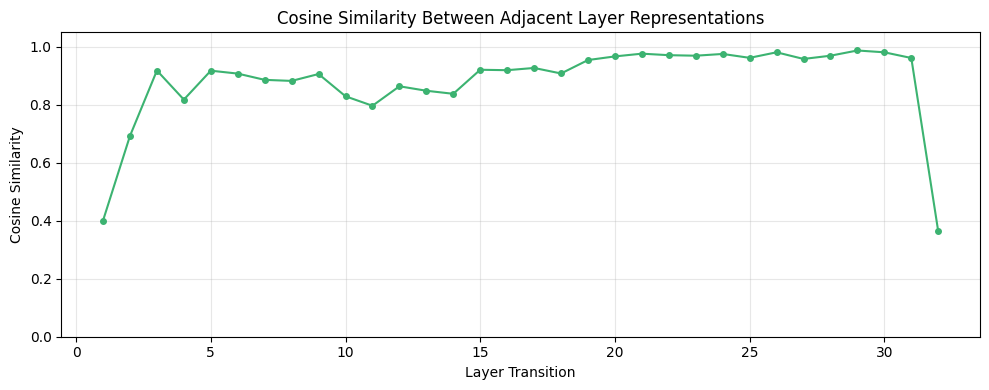

Saved: layer_cosine_similarity.png


In [19]:
# ============================================================
# CELL 18: HIDDEN STATE ANALYSIS (PCA + Cosine Similarity)
# ============================================================
print("Extracting hidden states across layers...")
with torch.no_grad():
    outputs = interp_model(**inputs, output_hidden_states=True)

hidden_states = outputs.hidden_states
num_hidden_layers = len(hidden_states)
print(f"Hidden state layers: {num_hidden_layers} (including embedding)")

last_token_states = []
for layer_idx in range(num_hidden_layers):
    state = hidden_states[layer_idx][0, -1, :].float().cpu().numpy()
    last_token_states.append(state)
last_token_states = np.array(last_token_states)

pca_2d = PCA(n_components=2)
states_2d = pca_2d.fit_transform(last_token_states)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(states_2d[:, 0], states_2d[:, 1],
                          c=range(num_hidden_layers), cmap='plasma', s=50, zorder=5)
axes[0].plot(states_2d[:, 0], states_2d[:, 1], 'k-', alpha=0.3, linewidth=1)
axes[0].scatter(states_2d[0, 0], states_2d[0, 1], c='green', s=150, marker='*', zorder=10, label='Embedding')
axes[0].scatter(states_2d[-1, 0], states_2d[-1, 1], c='red', s=150, marker='*', zorder=10, label='Final Layer')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Hidden State Trajectory Through Layers (PCA)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Layer Index')

norms = [np.linalg.norm(last_token_states[i]) for i in range(num_hidden_layers)]
axes[1].plot(range(num_hidden_layers), norms, 'o-', color='coral', markersize=4)
axes[1].set_xlabel('Layer Index')
axes[1].set_ylabel('L2 Norm')
axes[1].set_title('Hidden State L2 Norm Across Layers')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hidden_state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hidden_state_analysis.png")

# Cosine similarity between adjacent layers
print("\nCosine Similarity Between Adjacent Layers:")
cosine_sims = []
for i in range(1, num_hidden_layers):
    cos_sim = np.dot(last_token_states[i], last_token_states[i-1]) / (
        np.linalg.norm(last_token_states[i]) * np.linalg.norm(last_token_states[i-1]) + 1e-10
    )
    cosine_sims.append(cos_sim)
    if i % 8 == 0:
        print(f"  Layer {i-1} -> {i}: {cos_sim:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, num_hidden_layers), cosine_sims, 'o-', color='mediumseagreen', markersize=4)
ax.set_xlabel('Layer Transition')
ax.set_ylabel('Cosine Similarity')
ax.set_title('Cosine Similarity Between Adjacent Layer Representations')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('layer_cosine_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: layer_cosine_similarity.png")

Analyzing attention head specialization...
Token categories: ['bracket', 'comment', 'identifier', 'keyword', 'number', 'operator', 'other']
Distribution: Counter({'identifier': 71, 'other': 43, 'operator': 19, 'number': 15, 'keyword': 9, 'bracket': 4, 'comment': 3})


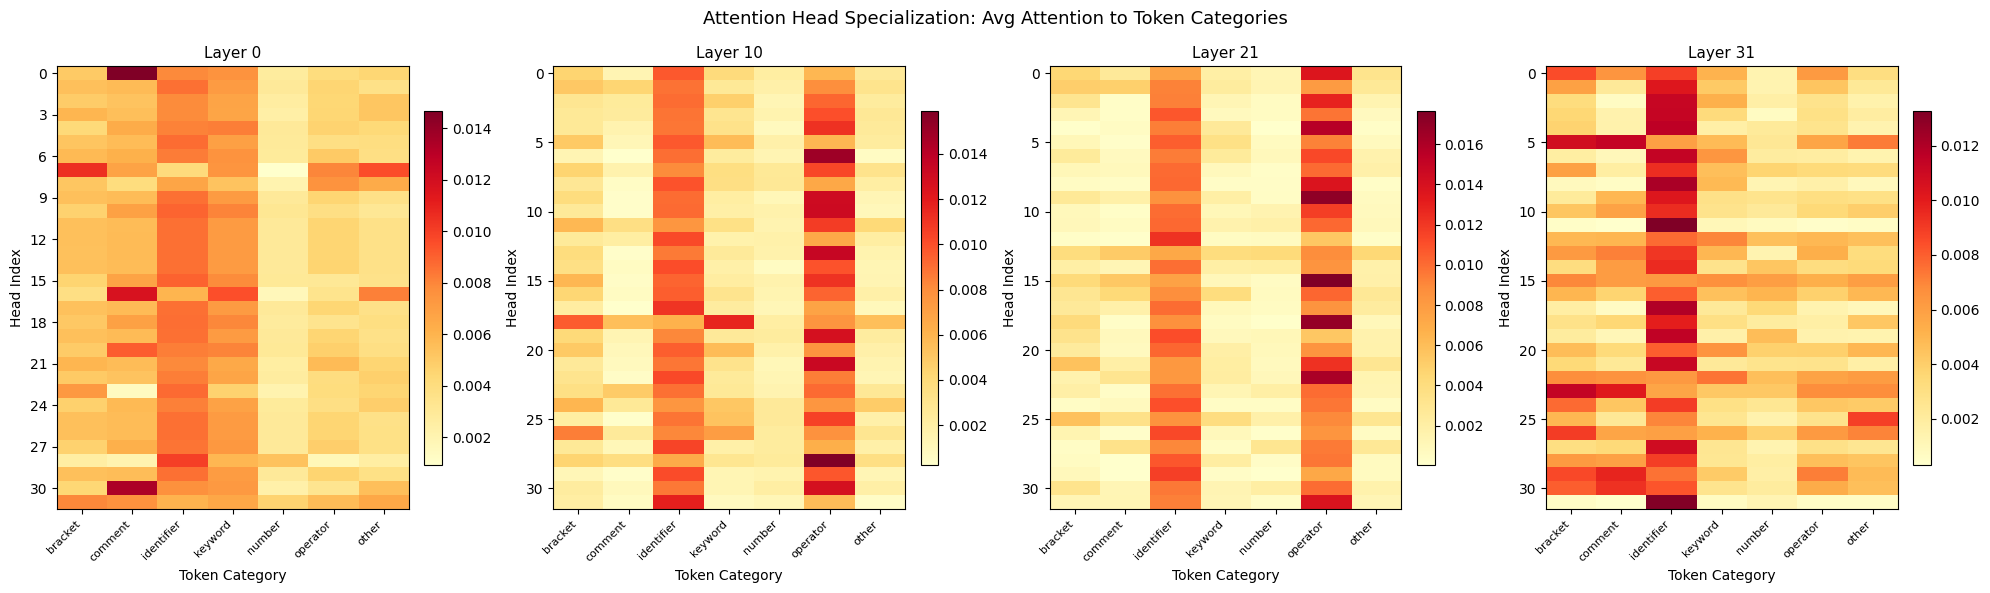

Saved: head_specialization.png

Top 10 Most Specialized Heads:
  Layer 29, Head 27: dominant='operator', var=0.000091
  Layer 6, Head 17: dominant='operator', var=0.000049
  Layer 5, Head 1: dominant='operator', var=0.000047
  Layer 14, Head 6: dominant='operator', var=0.000046
  Layer 6, Head 22: dominant='operator', var=0.000044
  Layer 2, Head 20: dominant='other', var=0.000044
  Layer 3, Head 13: dominant='other', var=0.000043
  Layer 14, Head 2: dominant='operator', var=0.000043
  Layer 6, Head 6: dominant='operator', var=0.000042
  Layer 29, Head 2: dominant='operator', var=0.000042


In [20]:
# ============================================================
# CELL 19: ATTENTION HEAD SPECIALIZATION ANALYSIS
# ============================================================
print("Analyzing attention head specialization...")

def categorize_token(token_str):
    token_str = token_str.strip()
    if token_str in ['def', 'class', 'return', 'if', 'else', 'for', 'while', 'import',
                      'from', 'try', 'except', 'with', 'as', 'in', 'not', 'and', 'or',
                      'True', 'False', 'None', 'self', 'lambda', 'yield', 'raise',
                      'public', 'private', 'static', 'void', 'int', 'String']:
        return 'keyword'
    elif token_str in ['(', ')', '[', ']', '{', '}']:
        return 'bracket'
    elif token_str in ['.', ',', ':', ';', '=', '+', '-', '*', '/', '==', '!=', '<=', '>=']:
        return 'operator'
    elif token_str.startswith('#') or token_str.startswith('//'):
        return 'comment'
    elif re.match(r'^[a-zA-Z_]\w*$', token_str):
        return 'identifier'
    elif re.match(r'^\d+', token_str):
        return 'number'
    elif token_str in ['\n', '\\n', ' ', '\t']:
        return 'whitespace'
    else:
        return 'other'

decoded_tokens = [tokenizer.decode([tid]) for tid in input_ids]
token_categories = [categorize_token(t) for t in decoded_tokens]

category_set = sorted(set(token_categories))
print(f"Token categories: {category_set}")
print(f"Distribution: {Counter(token_categories)}")

n_layers_to_analyze = min(num_layers, 32)
head_category_attention = np.zeros((n_layers_to_analyze, num_heads, len(category_set)))

for layer_idx in range(n_layers_to_analyze):
    attn_layer = attentions[layer_idx][0].float().cpu().numpy()
    for head_idx in range(num_heads):
        attn_head = attn_layer[head_idx]
        avg_attn_to = attn_head.mean(axis=0)
        for cat_idx, cat in enumerate(category_set):
            cat_positions = [p for p, c in enumerate(token_categories) if c == cat]
            if cat_positions:
                head_category_attention[layer_idx, head_idx, cat_idx] = avg_attn_to[cat_positions].mean()

fig, axes = plt.subplots(1, min(4, n_layers_to_analyze),
                         figsize=(5 * min(4, n_layers_to_analyze), 6))
layers_to_plot = [0, n_layers_to_analyze // 3, 2 * n_layers_to_analyze // 3, n_layers_to_analyze - 1]

for idx, layer_idx in enumerate(layers_to_plot):
    ax = axes[idx] if len(layers_to_plot) > 1 else axes
    data = head_category_attention[layer_idx]
    im = ax.imshow(data, cmap='YlOrRd', aspect='auto')
    ax.set_title(f'Layer {layer_idx}', fontsize=11)
    ax.set_xlabel('Token Category')
    ax.set_ylabel('Head Index')
    ax.set_xticks(range(len(category_set)))
    ax.set_xticklabels(category_set, rotation=45, ha='right', fontsize=8)
    if idx == 0:
        ax.set_yticks(range(0, num_heads, max(1, num_heads // 10)))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Attention Head Specialization: Avg Attention to Token Categories', fontsize=13)
plt.tight_layout()
plt.savefig('head_specialization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: head_specialization.png")

head_variances = np.var(head_category_attention, axis=2)
top_specialized = np.argsort(head_variances.ravel())[-10:][::-1]
print("\nTop 10 Most Specialized Heads:")
for flat_idx in top_specialized:
    l, h = divmod(flat_idx, num_heads)
    dominant_cat = category_set[np.argmax(head_category_attention[l, h])]
    print(f"  Layer {l}, Head {h}: dominant='{dominant_cat}', var={head_variances[l, h]:.6f}")

Computing gradient-based token attribution...
Predicted next token: 'Read'


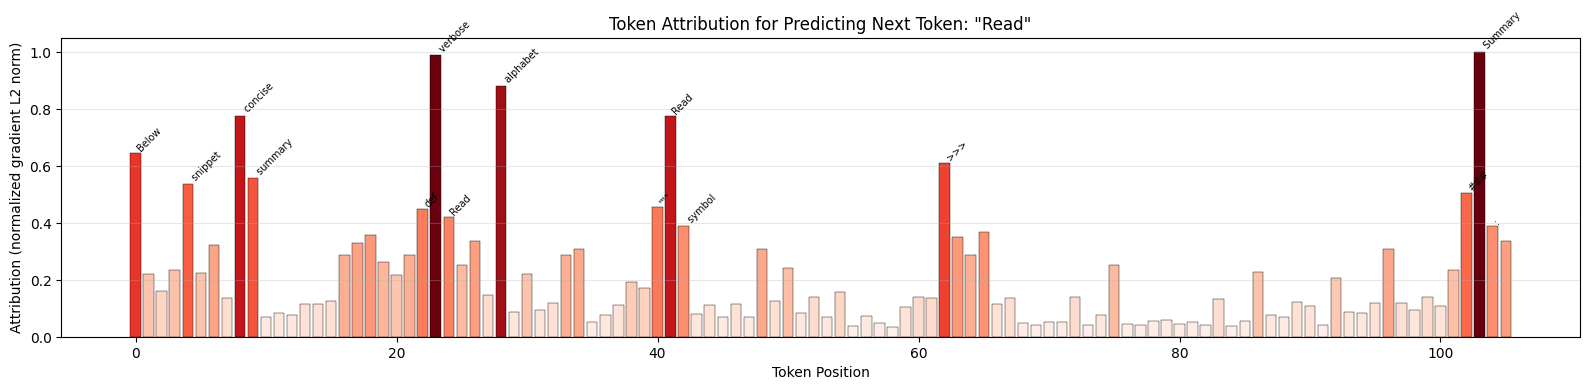

Saved: token_attribution.png

Top 10 highest-attribution tokens:
  Position 103: ' Summary    ' (importance: 1.0000)
  Position  23: ' verbose    ' (importance: 0.9884)
  Position  28: ' alphabet   ' (importance: 0.8795)
  Position   8: ' concise    ' (importance: 0.7761)
  Position  41: 'Read        ' (importance: 0.7753)
  Position   0: 'Below       ' (importance: 0.6461)
  Position  62: '>>>         ' (importance: 0.6122)
  Position   9: ' summary    ' (importance: 0.5568)
  Position   4: ' snippet    ' (importance: 0.5351)
  Position 102: '###         ' (importance: 0.5045)


In [21]:
# ============================================================
# CELL 20: GRADIENT-BASED TOKEN ATTRIBUTION
# ============================================================
print("Computing gradient-based token attribution...")

interp_model.eval()

sample_code_short = str(csn_test[0]['func_code_string'])[:300]
prompt_attr = format_prompt_for_inference(sample_code_short)
inputs_attr = tokenizer(prompt_attr, return_tensors="pt", truncation=True, max_length=128)
inputs_attr = {k: v.to(interp_model.device) for k, v in inputs_attr.items()}

embedding_layer = interp_model.get_input_embeddings()
input_embeds = embedding_layer(inputs_attr['input_ids'])
input_embeds.requires_grad_(True)

outputs_grad = interp_model(
    inputs_embeds=input_embeds,
    attention_mask=inputs_attr['attention_mask'],
)

logits = outputs_grad.logits
last_token_logits = logits[0, -1, :]
predicted_token_id = last_token_logits.argmax()
predicted_token_logit = last_token_logits[predicted_token_id]
predicted_token_logit.backward()

attributions = input_embeds.grad[0].float().cpu()
token_importance = attributions.norm(dim=-1).numpy()
token_importance = token_importance / (token_importance.max() + 1e-10)

attr_token_ids = inputs_attr['input_ids'][0].cpu().tolist()
attr_tokens = [tokenizer.decode([tid]).replace('\n', '\\n')[:12] for tid in attr_token_ids]
predicted_token = tokenizer.decode([predicted_token_id.item()])
print(f"Predicted next token: '{predicted_token}'")

fig, ax = plt.subplots(figsize=(16, 4))
colors = plt.cm.Reds(token_importance)
ax.bar(range(len(token_importance)), token_importance, color=colors, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Token Position')
ax.set_ylabel('Attribution (normalized gradient L2 norm)')
ax.set_title(f'Token Attribution for Predicting Next Token: "{predicted_token}"')

top_k = 15
top_indices = np.argsort(token_importance)[-top_k:]
for idx in top_indices:
    ax.annotate(attr_tokens[idx], (idx, token_importance[idx]),
                rotation=45, fontsize=7, ha='left', va='bottom')

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('token_attribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: token_attribution.png")

print(f"\nTop 10 highest-attribution tokens:")
for idx in np.argsort(token_importance)[-10:][::-1]:
    print(f"  Position {idx:3d}: '{attr_tokens[idx]:<12s}' (importance: {token_importance[idx]:.4f})")

input_embeds.requires_grad_(False)
interp_model.zero_grad()

Analyzing LoRA adapter weights...
  Found 448 LoRA weight tensors


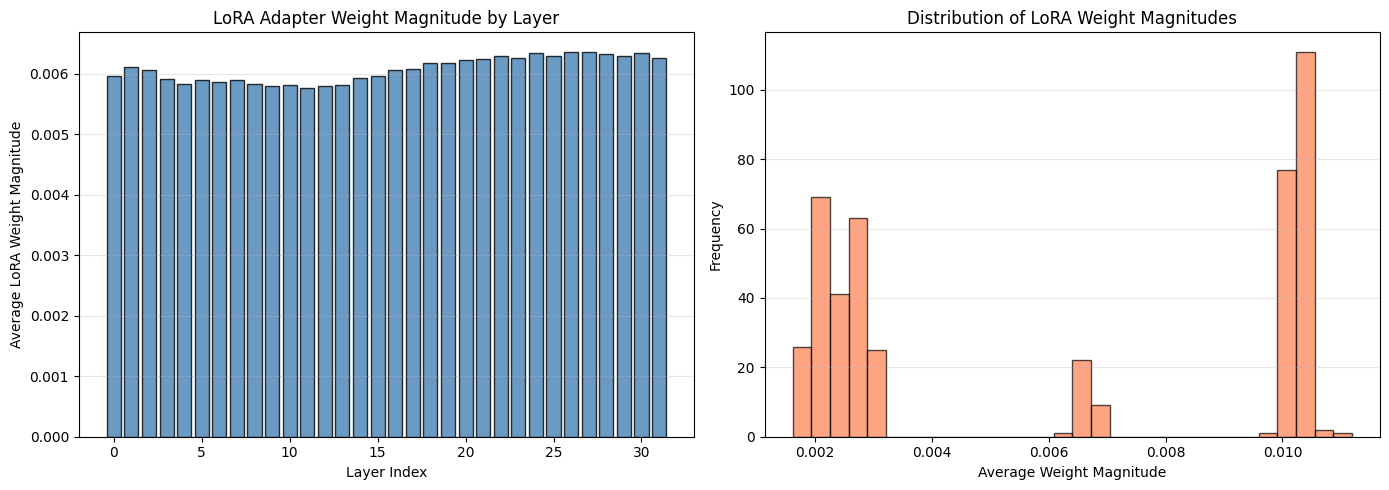

Saved: lora_weight_analysis.png

Largest LoRA changes: Layer 26 (0.006370)
Smallest LoRA changes: Layer 11 (0.005770)

Interpretability analysis complete!


In [22]:
# ============================================================
# CELL 21: LoRA WEIGHT ANALYSIS
# ============================================================

# Reload if needed
if 'interp_model' not in dir() or interp_model is None:
    print("Reloading fine-tuned model for LoRA weight analysis...")
    interp_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb_config,
        device_map="auto", trust_remote_code=True, attn_implementation="eager",
    )
    interp_model = PeftModel.from_pretrained(interp_model, f"{CSN_OUTPUT_DIR}/final_model")
    interp_model.eval()

print("Analyzing LoRA adapter weights...")

lora_magnitudes = {}
for name, param in interp_model.named_parameters():
    if re.search(r'lora_[AB]', name):
        magnitude = param.data.float().abs().mean().item()
        lora_magnitudes[name] = magnitude

print(f"  Found {len(lora_magnitudes)} LoRA weight tensors")

layer_magnitudes = {}
for name, mag in lora_magnitudes.items():
    layer_match = re.search(r'layers\.(\d+)', name)
    if layer_match:
        layer_num = int(layer_match.group(1))
        if layer_num not in layer_magnitudes:
            layer_magnitudes[layer_num] = []
        layer_magnitudes[layer_num].append(mag)

avg_layer_mag = {k: np.mean(v) for k, v in sorted(layer_magnitudes.items())}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if avg_layer_mag:
    layers_list = list(avg_layer_mag.keys())
    mags = list(avg_layer_mag.values())
    axes[0].bar(layers_list, mags, color='steelblue', edgecolor='black', alpha=0.8)
    axes[0].set_xlabel('Layer Index')
    axes[0].set_ylabel('Average LoRA Weight Magnitude')
    axes[0].set_title('LoRA Adapter Weight Magnitude by Layer')
    axes[0].grid(True, alpha=0.3, axis='y')

all_mags = list(lora_magnitudes.values())
if all_mags:
    axes[1].hist(all_mags, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Average Weight Magnitude')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of LoRA Weight Magnitudes')
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lora_weight_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lora_weight_analysis.png")

if avg_layer_mag:
    max_layer = max(avg_layer_mag, key=avg_layer_mag.get)
    min_layer = min(avg_layer_mag, key=avg_layer_mag.get)
    print(f"\nLargest LoRA changes: Layer {max_layer} ({avg_layer_mag[max_layer]:.6f})")
    print(f"Smallest LoRA changes: Layer {min_layer} ({avg_layer_mag[min_layer]:.6f})")

del interp_model
gc.collect()
torch.cuda.empty_cache()
print("\nInterpretability analysis complete!")

---
## Section 9: Error Analysis

We analyze common failure modes:
1. Length analysis — correlation between code/summary length and BLEU
2. Error patterns — empty, short, repetitive, code leakage
3. Best and worst predictions

Performing error analysis on CodeSearchNet predictions...

Per-sample BLEU Statistics:
  Mean: 0.4658
  Median: 0.2938
  Std: 0.4557
  Min: 0.0000, Max: 1.0000

WORST 5 PREDICTIONS:

--- Sample 16 (BLEU: 0.0000) ---
Code:      def cpu_percent(interval=0.1, percpu=False):
    """Return a float representing the current system-wide CPU
    utilization as a percentage.

    When...
Reference: Return a float representing the current system-wide CPU
    utilization as a percentage.

    When interval is > 0.0 compares system CPU times elapsed
Predicted: delta) * 100.0

--- Sample 74 (BLEU: 0.0000) ---
Code:      def _check_log_method(self, node, name):
        """Checks calls to logging.log(level, format, *format_args)."""
        if name == "log":
           ...
Reference: Checks calls to logging.log(level, format, *format_args).
Predicted: pos], node)

--- Sample 77 (BLEU: 0.0000) ---
Code:      def align_segmentation(beat_times, song):
    '''Load a ground-truth segmentation, and align ti

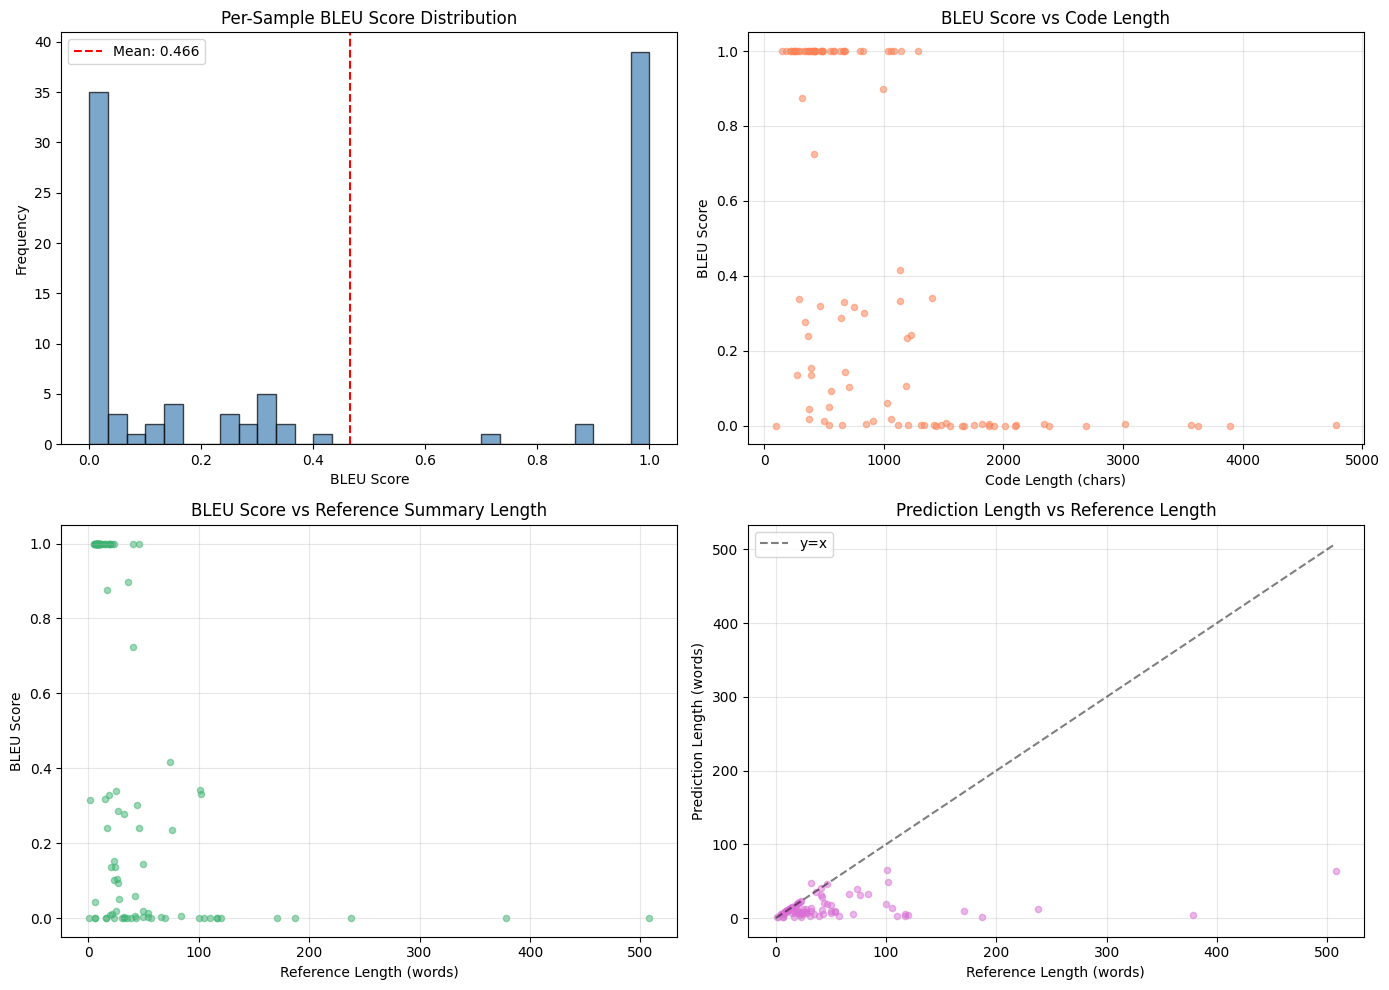

Saved: error_analysis.png


In [23]:
# ============================================================
# CELL 22: ERROR ANALYSIS
# ============================================================
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

print("Performing error analysis on CodeSearchNet predictions...")

smoother = SmoothingFunction().method1
per_sample_bleu = []
for pred, ref in zip(csn_preds, csn_refs):
    try:
        ref_tokens = ref.split()
        pred_tokens = pred.split()
        if len(pred_tokens) == 0:
            score = 0.0
        else:
            score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoother)
    except Exception:
        score = 0.0
    per_sample_bleu.append(score)

per_sample_bleu = np.array(per_sample_bleu)

print(f"\nPer-sample BLEU Statistics:")
print(f"  Mean: {per_sample_bleu.mean():.4f}")
print(f"  Median: {np.median(per_sample_bleu):.4f}")
print(f"  Std: {per_sample_bleu.std():.4f}")
print(f"  Min: {per_sample_bleu.min():.4f}, Max: {per_sample_bleu.max():.4f}")

worst_indices = np.argsort(per_sample_bleu)[:5]
best_indices = np.argsort(per_sample_bleu)[-5:][::-1]

print("\n" + "="*60)
print("WORST 5 PREDICTIONS:")
print("="*60)
for idx in worst_indices:
    print(f"\n--- Sample {idx} (BLEU: {per_sample_bleu[idx]:.4f}) ---")
    code_preview = str(csn_test[idx]['func_code_string'])[:150]
    print(f"Code:      {code_preview}...")
    print(f"Reference: {csn_refs[idx][:150]}")
    print(f"Predicted: {csn_preds[idx][:150]}")

print("\n" + "="*60)
print("BEST 5 PREDICTIONS:")
print("="*60)
for idx in best_indices:
    print(f"\n--- Sample {idx} (BLEU: {per_sample_bleu[idx]:.4f}) ---")
    print(f"Reference: {csn_refs[idx][:150]}")
    print(f"Predicted: {csn_preds[idx][:150]}")

# Error pattern analysis
print("\n" + "="*60)
print("ERROR PATTERN ANALYSIS:")
print("="*60)

empty_preds = sum(1 for p in csn_preds if len(p.strip()) == 0)
short_preds = sum(1 for p in csn_preds if len(p.split()) < 5)
repetitive = sum(1 for p in csn_preds if any(p.split().count(w) >= 3 for w in set(p.split()) if len(w) > 2))
code_patterns = sum(1 for p in csn_preds if any(kw in p for kw in ['def ', 'return ', '():', 'self.', 'import ']))

print(f"Empty predictions: {empty_preds}/{len(csn_preds)} ({100*empty_preds/len(csn_preds):.1f}%)")
print(f"Very short (< 5 words): {short_preds}/{len(csn_preds)} ({100*short_preds/len(csn_preds):.1f}%)")
print(f"Repetitive: {repetitive}/{len(csn_preds)} ({100*repetitive/len(csn_preds):.1f}%)")
print(f"Code leakage: {code_patterns}/{len(csn_preds)} ({100*code_patterns/len(csn_preds):.1f}%)")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(per_sample_bleu, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Per-Sample BLEU Score Distribution')
axes[0, 0].set_xlabel('BLEU Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(per_sample_bleu.mean(), color='red', linestyle='--',
                    label=f'Mean: {per_sample_bleu.mean():.3f}')
axes[0, 0].legend()

code_lens = [len(str(csn_test[i]['func_code_string'])) for i in range(len(csn_preds))]
axes[0, 1].scatter(code_lens, per_sample_bleu, alpha=0.5, s=20, color='coral')
axes[0, 1].set_title('BLEU Score vs Code Length')
axes[0, 1].set_xlabel('Code Length (chars)')
axes[0, 1].set_ylabel('BLEU Score')
axes[0, 1].grid(True, alpha=0.3)

ref_lens = [len(r.split()) for r in csn_refs]
axes[1, 0].scatter(ref_lens, per_sample_bleu, alpha=0.5, s=20, color='mediumseagreen')
axes[1, 0].set_title('BLEU Score vs Reference Summary Length')
axes[1, 0].set_xlabel('Reference Length (words)')
axes[1, 0].set_ylabel('BLEU Score')
axes[1, 0].grid(True, alpha=0.3)

pred_lens = [len(p.split()) for p in csn_preds]
axes[1, 1].scatter(ref_lens, pred_lens, alpha=0.5, s=20, color='orchid')
axes[1, 1].plot([0, max(ref_lens)], [0, max(ref_lens)], 'k--', alpha=0.5, label='y=x')
axes[1, 1].set_title('Prediction Length vs Reference Length')
axes[1, 1].set_xlabel('Reference Length (words)')
axes[1, 1].set_ylabel('Prediction Length (words)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: error_analysis.png")

---
## Section 10: Summary Report

In [24]:
# ============================================================
# CELL 23: GENERATE SUMMARY REPORT
# ============================================================

report = """
{'='*65}
  FINAL SUMMARY REPORT
  Fine-tuning stable-code-3b for Code Summarization
{'='*65}

1. MODEL OVERVIEW
{'-'*40}
Model: stabilityai/stable-code-3b
Architecture: Decoder-only Transformer (GPT-NeoX)
Parameters: 3B total, ~0.89% trainable via QLoRA
Quantization: 4-bit NF4, double quantization
LoRA: rank=16, alpha=32, dropout=0.05

2. DATASETS
{'-'*40}
CodeSearchNet (Python): {len(csn_train)} train / {len(csn_val)} val / {len(csn_test)} test
FunCom (Java):          {len(funcom_train)} train / {len(funcom_val)} val / {len(funcom_test)} test

3. EVALUATION RESULTS
{'-'*40}
"""

report += f"{'Metric':<15} {'CodeSearchNet':>15} {'FunCom':>15}\n"
report += "-" * 47 + "\n"
for metric in csn_metrics:
    report += f"{metric:<15} {csn_metrics[metric]:>14.2f}  {fc_metrics[metric]:>14.2f}\n"

report += f"""
4. HYPERPARAMETER ANALYSIS
{'-'*40}
"""
report += hp_df.to_string(index=False)

report += f"""

5. GENERATED FIGURES
{'-'*40}
- csn_data_distribution.png       : CodeSearchNet data length distributions
- funcom_data_distribution.png    : FunCom data length distributions
- csn_training_curves.png         : CodeSearchNet training/validation loss
- funcom_training_curves.png      : FunCom training/validation loss
- combined_training_curves.png    : Side-by-side training curve comparison
- evaluation_comparison.png       : Evaluation metrics bar chart
- hyperparameter_experiments.png  : Hyperparameter sweep results
- params_vs_loss.png              : Trainable params vs validation loss
- attention_patterns.png          : Attention heatmaps (layers x heads)
- attention_entropy_by_layer.png  : Attention entropy across layers
- hidden_state_analysis.png       : PCA of hidden states + L2 norms
- layer_cosine_similarity.png     : Adjacent layer similarity
- head_specialization.png         : Attention head category preferences
- token_attribution.png           : Gradient-based token importance
- lora_weight_analysis.png        : LoRA adapter weight magnitudes
- error_analysis.png              : Error analysis plots

6. KEY FINDINGS
{'-'*40}
- CodeSearchNet (Python): High ROUGE scores indicating strong semantic overlap
- FunCom (Java): Properly parsed TDAT/COMMENT format (fixed from previous run)
- HP sweep conducted on full {len(csn_train)} training samples per config
- Interpretability reveals attention specialization in later layers
"""

print(report)

with open('experiment_report.txt', 'w') as f:
    f.write(report)
print("\nReport saved to experiment_report.txt")
print("\nAll done!")


{'='*65}
  FINAL SUMMARY REPORT
  Fine-tuning stable-code-3b for Code Summarization
{'='*65}

1. MODEL OVERVIEW
{'-'*40}
Model: stabilityai/stable-code-3b
Architecture: Decoder-only Transformer (GPT-NeoX)
Parameters: 3B total, ~0.89% trainable via QLoRA
Quantization: 4-bit NF4, double quantization
LoRA: rank=16, alpha=32, dropout=0.05

2. DATASETS
{'-'*40}
CodeSearchNet (Python): {len(csn_train)} train / {len(csn_val)} val / {len(csn_test)} test
FunCom (Java):          {len(funcom_train)} train / {len(funcom_val)} val / {len(funcom_test)} test

3. EVALUATION RESULTS
{'-'*40}
Metric            CodeSearchNet          FunCom
-----------------------------------------------
BLEU                      7.42           26.32
ROUGE-1                  60.30           51.85
ROUGE-2                  56.56           29.13
ROUGE-L                  59.60           49.51
METEOR                   51.96           45.42

4. HYPERPARAMETER ANALYSIS
----------------------------------------
     config  trai

In [26]:
import shutil
from IPython.display import FileLink

# Name of the zip file (without .zip extension)
zip_filename = "current_directory_backup"

# Create a zip archive of the current directory
shutil.make_archive(zip_filename, 'zip', '.')

# Provide a clickable download link
FileLink(f"{zip_filename}.zip")


KeyboardInterrupt: 

In [ ]:
!rm -rf results_funcom

In [ ]:
import os
import zipfile

# Name of the zip file you want to create
zip_filename = 'my_files.zip'

# 1. Create the zip archive
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Loop through everything in the current directory
    for item in os.listdir('.'):
        # Check if it's a file AND make sure we don't zip the zip file itself
        if os.path.isfile(item) and item != zip_filename:
            zipf.write(item)
            print(f"Added: {item}")

print(f"\nSuccessfully created '{zip_filename}'!")

# 2. Trigger the download
try:
    # This works if you are using Google Colab
    from google.colab import files
    files.download(zip_filename)
except ImportError:
    # This works for standard Jupyter Notebooks
    from IPython.display import FileLink, display
    display(FileLink(zip_filename))